# Task 3. Binäre Klassifikation mit mehrschichtigem Perzeptron (Multilayer Perceptron, MLP) (+ Channel-Unterscheidung)

# Installs

In [61]:
%pip install numpy 
%pip install pandas 
%pip install scipy 
%pip install matplotlib
%pip install seaborn
%pip install sklearn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Imports

In [52]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, matplotlib.cm as cm
import soundfile as sf
import seaborn as sns
from scipy.io import wavfile
from scipy.signal import stft
from scipy.stats import entropy, gmean, kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding, MDS, SpectralEmbedding
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

## 1. Loading the files and creating a data frame

1.1 

In [5]:
# - Durchsucht Unterordner Z01 bis Z05 jeweils in deren Wav-Unterordner
pattern = os.path.join('*Datei', 'sig', 'Z*', 'Z*', 'Z*', 'Wav', '*.wav')

# Alle Dateien finden, die dem Muster entsprechen
files = glob.glob(pattern)
print(len(files), 'files', '\n', files[264])  # Print for Error-Checks


440 files 
 Seminaraufgabe_2_Datei\sig\Z03\Z03_Pos06_RC2_75k_0000\Z03_Pos06_RC2_75k_0000_1307031507\Wav\Z03_Pos06_RC2_75k_0000_1307031507_00000_14_Ch1.wav


1.2

In [6]:
data = []

# Durchläuft alle gefundenen Dateien
for fn in files:
    try:
        # fs = Abtastrate (Sampling Frequency)
        signal, fs = sf.read(fn)
    except Exception as e:
        # Print for Error
        print(f"Fehler beim Lesen von {fn}: {e}")
        continue  # Überspringt fehlerhafte Datei

    # Extrahiert Dateinamen
    basename = os.path.basename(fn)
    parts = basename.split('_')

    # Erstellt Datensatz mit Metadaten und Signal (Keys der Aufgabenstellung entsprechend)
    entry = {
        'fn': basename,         
        'sig': signal,     
        'spec': parts[0],  
        'mID': parts[4],   
        'time': parts[5],  
        'rID': parts[6],     
        'sID': parts[8][:-4],  
        'stft': None       
    }
    
    data.append(entry)  # Fügt Datensatz zur Liste hinzu

# Erstellt DataFrame aus der Liste
df = pd.DataFrame(data)

# Zeigt die ersten 5 Einträge zur Qualitätskontrolle (Error-Checking)
print("DataFrame-Übersicht:")
print(df.head())

DataFrame-Übersicht:
                                                  fn  \
0  Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch1...   
1  Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch2...   
2  Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch1...   
3  Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch2...   
4  Z01_Pos00_RC2_75k_0001_1312091511_00000_14_Ch1...   

                                                 sig spec   mID        time  \
0  [0.00048828125, 0.00244140625, 0.0029296875, 0...  Z01  0000  1307031427   
1  [0.001953125, 0.0, 0.00146484375, 0.001953125,...  Z01  0000  1307031427   
2  [0.00146484375, 0.0, 0.00048828125, 0.00195312...  Z01  0000  1307031427   
3  [-0.00048828125, 0.0009765625, 0.0, -0.0009765...  Z01  0000  1307031427   
4  [0.00048828125, 0.00146484375, 0.00048828125, ...  Z01  0001  1312091511   

     rID  sID  stft  
0  00000  Ch1  None  
1  00000  Ch2  None  
2  00001  Ch1  None  
3  00001  Ch2  None  
4  00000  Ch1  None  


## 2. Applying STFT

2.1

In [7]:
for idx, row in df.iterrows():
    fs = 1e6  # Anpassen an reale Abtastrate
    f, t, Zxx = stft(row['sig'], 
                    fs=fs,
                    window='hann', 
                    nperseg=512,    # Fensterlänge
                    noverlap=256)   # 50% Overlap
    
    df.at[idx, 'stft'] = (f, t, np.abs(Zxx))

2.2

In [8]:
def plot_spectrogram_signal(row, nfft=2048, noverlap=1024, fmax=100000):
    signal = row['sig']

    # Setzt die Abtastrate (Samplingrate); falls nicht im DataFrame, Standardwert verwenden
    fs = row.get('fs', 1041666)  # ggf. anpassen!

    # Erstellt eine neue Abbildung für das Spektrogramm
    plt.figure(figsize=(10, 5))

    # Berechnet und plottet das Spektrogramm des Signals:
    
    Pxx, freqs, bins, im = plt.specgram(
        signal,                 # Zeitsignal
        NFFT=nfft,              # Fensterlänge für die FFT (hier 2048 Samples)
        Fs=fs,                  # Abtastrate in Hz
        noverlap=noverlap,      # Überlappung zwischen den Fenstern (hier 1024 Samples)
        scale='dB',             # Amplituden werden in Dezibel dargestellt
        cmap='magma'          # Farbskala für die Darstellung (gelb, grün, türkis)
    )

    plt.title(f"Spektrogramm {row['spec']} - {row['sID']}")     # Titel 
    plt.ylabel('Frequenz [Hz]')                                 # y-Achse
    plt.xlabel('Zeit [s]')                                      # x-Achse
    plt.ylim(0, fmax)                                           # Relevanten Bereich zeigen (100 kHz)

    # Fügt eine Farbskala hinzu, die die Amplitude in dB anzeigt
    plt.colorbar(label='Amplitude [dB]')
    
    plt.tight_layout()
    plt.show()

2.3


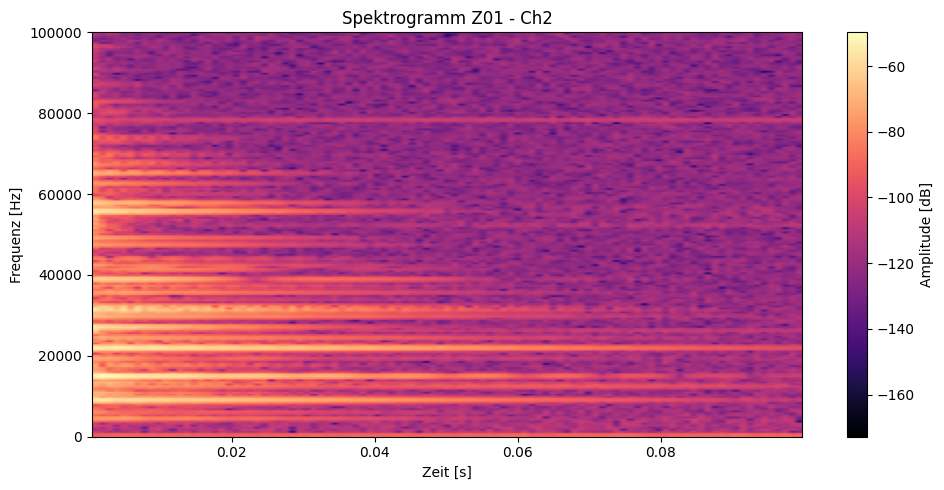

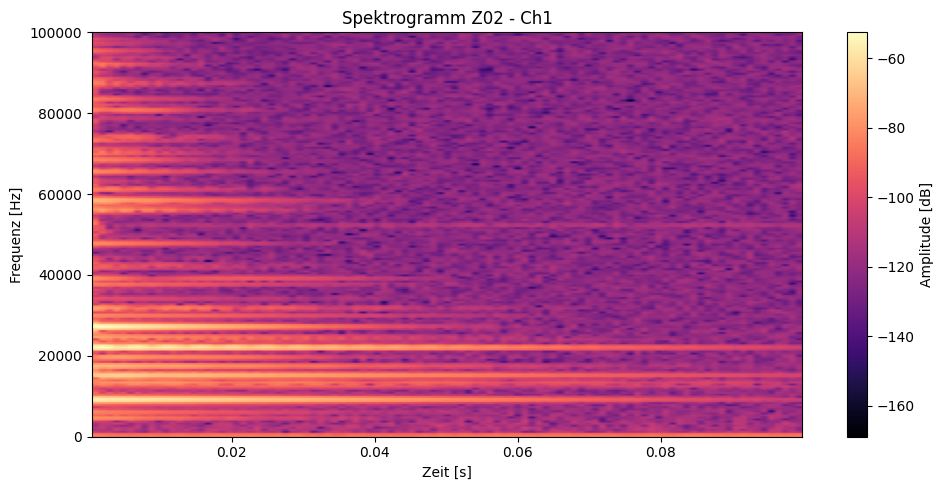

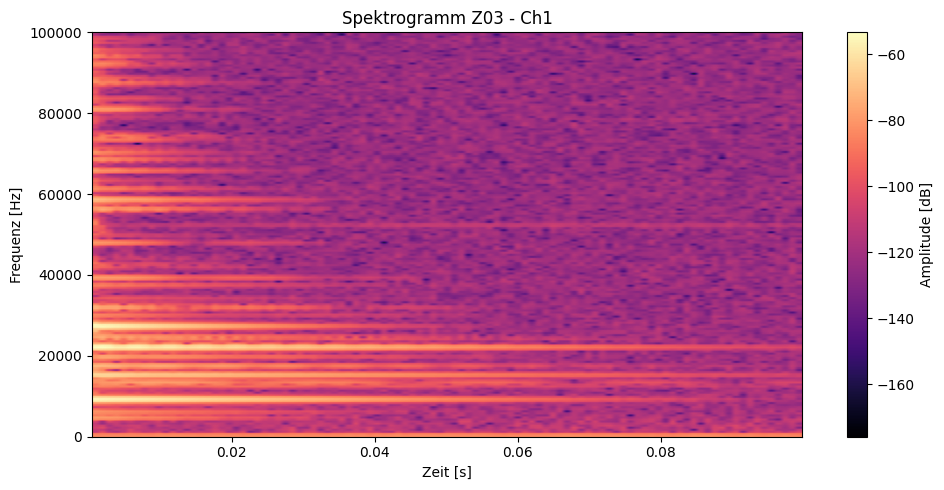

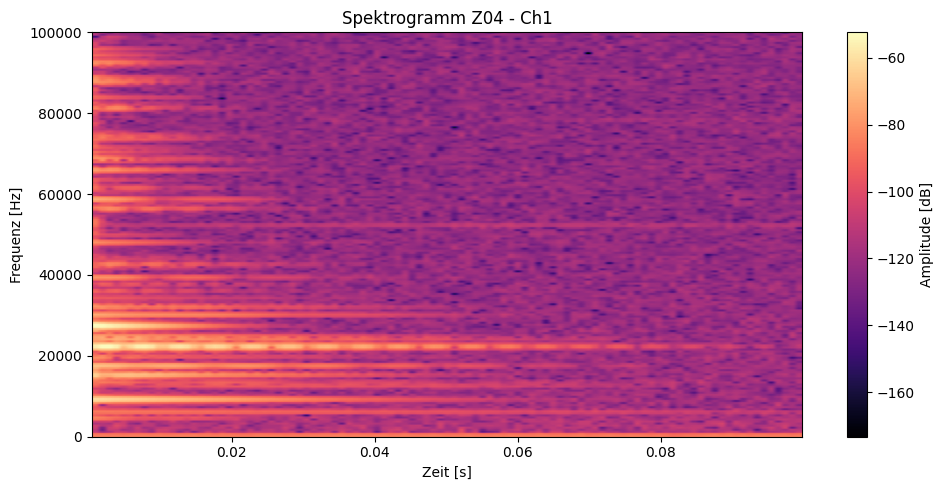

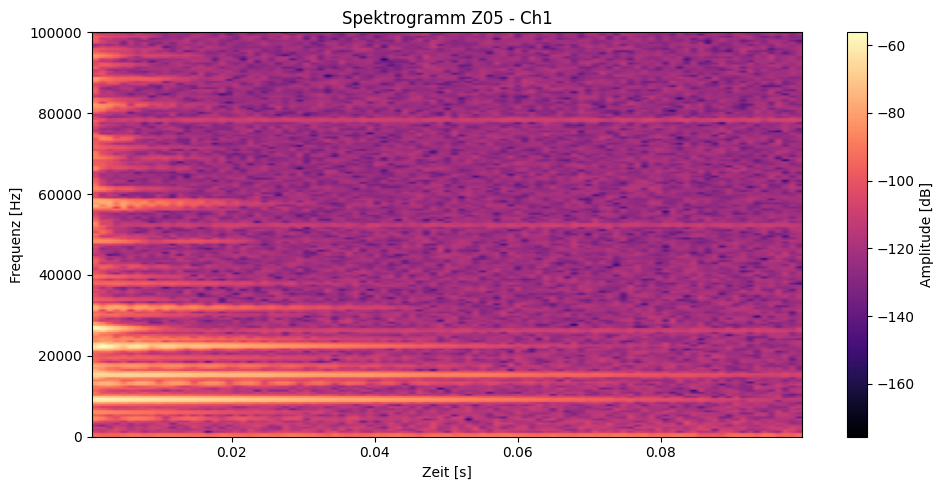

In [9]:
sampleset=[1, 228, 254, 370, 420]
for i in sampleset:
    plot_spectrogram_signal(df.iloc[i])

## 3. Feature extraction

3.1

In [10]:
def analyze_stft(stft):
    magnitude = np.abs(stft[2])
    mag_mean = np.mean(magnitude, axis=1)  # magnitude averaged by time
    spectral_mean = np.sum(stft[0] * mag_mean) / np.sum(mag_mean) # average frequency, weighted by magnitude
    spectral_variance = np.sum(((stft[0] - spectral_mean) ** 2) * mag_mean) / np.sum(mag_mean) #distance of each frequency bin from the mean
    upper_half = mag_mean[len(stft[0])//2:]
    prob_dist = upper_half / np.sum(upper_half)
    entropy_upper = entropy(prob_dist) # how irregular the upper part of the spectrum is
    flatness = gmean(upper_half + 1e-8) / np.mean(upper_half) # how much noise there is
    cumulative_energy = np.cumsum(mag_mean)
    rolloff_idx = np.searchsorted(cumulative_energy, 0.85 * cumulative_energy[-1])
    rolloff_freq = stft[0][rolloff_idx]  # 85% of energy is below this frequency
    kurt_upper = kurtosis(upper_half) # reflects spikiness or asymmetry in the upper band
    
    return spectral_mean, spectral_variance, entropy_upper, flatness, rolloff_freq, kurt_upper


def analyze_signal(sig):
    signal_mean = np.mean(sig)
    signal_variance = np.var(sig)
    signal_skewness = skew(sig)
    signal_kurtosis = kurtosis(sig)  # fourth moment
    signal_rms = np.sqrt(np.mean(sig**2))
    signal_peak = np.max(np.abs(sig))  # peak amplitude
    return signal_mean, signal_variance, signal_skewness, signal_rms, signal_peak, signal_kurtosis



3.2

In [11]:
featureslist = ['sig_mean', 'sig_var', 'sig_skew', 'sig_rms', 'sig_peak', 
                'sig_kurtosis',
                'spec_mean', 'spec_var', 'spec_entropy_up', 'spec_flatness', 
                'spec_rolloff_freq', 'spec_kurtosis']

# Kanal-Information als Feature
df['channel'] = df['sID'].apply(lambda x: 1 if 'Ch1' in x else 2)
featureslist.append('channel')

# Label für Klassifikation 
df['label'] = df['spec'].apply(lambda x: 0 if 'Z05' in x else 1)

features_to_init = [f for f in featureslist if f not in ['channel', 'label']]
for feature in features_to_init:
    df[feature] = None

3.3

In [12]:
for idx, row in df.iterrows():
    sig = row['sig']
    sig_mean, sig_var, sig_skew, sig_rms, sig_peak, sig_kurtosis = analyze_signal(sig)
    df.at[idx, 'sig_mean'] = sig_mean
    df.at[idx, 'sig_var'] = sig_var
    df.at[idx, 'sig_skew'] = sig_skew
    df.at[idx, 'sig_rms'] = sig_rms
    df.at[idx, 'sig_peak'] = sig_peak
    df.at[idx, 'sig_kurtosis'] = sig_kurtosis
    
    stft = row['stft']
    if stft is None:  # Kritische Prüfung
        print(f"Fehler: Keine STFT-Daten für {row['fn']}")
        continue
    
    spectral_mean, spectral_variance, entropy_upper, flatness, rolloff_freq, kurt_upper = analyze_stft(stft)
    df.at[idx, 'spec_mean'] = spectral_mean
    df.at[idx, 'spec_var'] = spectral_variance
    df.at[idx, 'spec_entropy_up'] = entropy_upper
    df.at[idx, 'spec_flatness'] = flatness
    df.at[idx, 'spec_rolloff_freq'] = rolloff_freq
    df.at[idx, 'spec_kurtosis'] = kurt_upper

# Daten für ML vorbereiten
X = df[featureslist]
y = df['label']

# Skalierung
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


   

3.4

In [13]:

df.head(3)

,fn,sig,spec,mID,time,rID,sID,stft,channel,label,...,sig_skew,sig_rms,sig_peak,sig_kurtosis,spec_mean,spec_var,spec_entropy_up,spec_flatness,spec_rolloff_freq,spec_kurtosis
0,Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch1...,"[0.00048828125, 0.00244140625, 0.0029296875, 0...",Z01,0000,1307031427,00000,Ch1,"([0.0, 1953.125, 3906.25, 5859.375, 7812.5, 97...",1,1,...,-0.020609,0.028749,0.272095,16.887122,55102.270438,9724635359.652275,4.66887,0.870555,76171.875,27.552674
1,Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch2...,"[0.001953125, 0.0, 0.00146484375, 0.001953125,...",Z01,0000,1307031427,00000,Ch2,"([0.0, 1953.125, 3906.25, 5859.375, 7812.5, 97...",2,1,...,-0.173273,0.039612,0.457214,16.392937,51765.810211,8161863944.32345,4.562784,0.817427,54687.5,37.586437
2,Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch1...,"[0.00146484375, 0.0, 0.00048828125, 0.00195312...",Z01,0000,1307031427,00001,Ch1,"([0.0, 1953.125, 3906.25, 5859.375, 7812.5, 97...",1,1,...,0.003026,0.028963,0.274536,16.867039,51583.906401,8757124448.875418,4.692256,0.900276,64453.125,45.445533


## 4. Feature overview using Matplotlib

4.1 

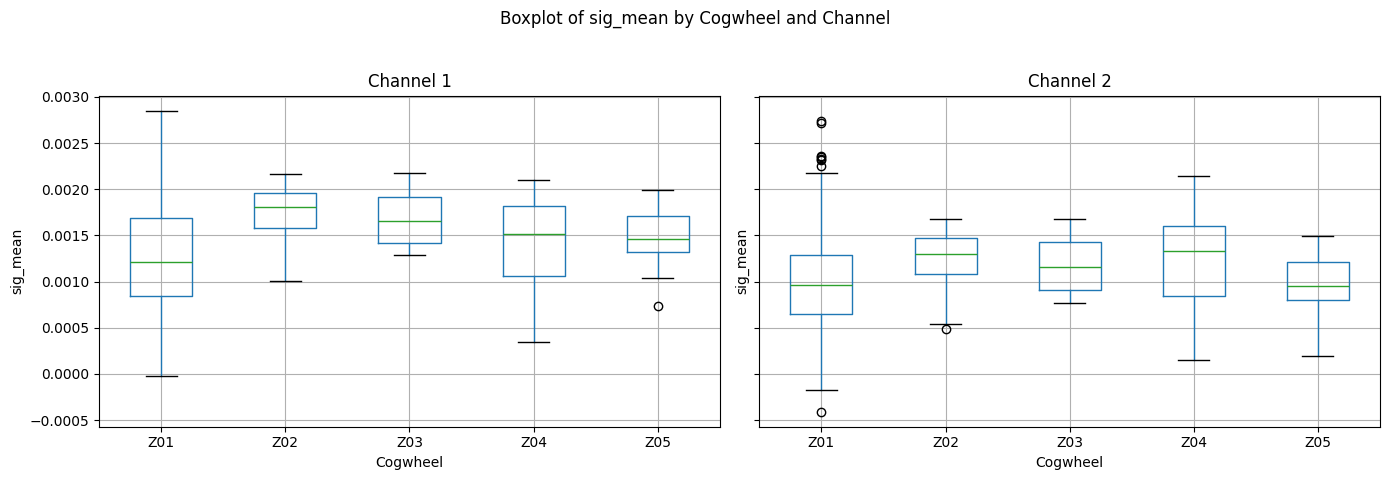

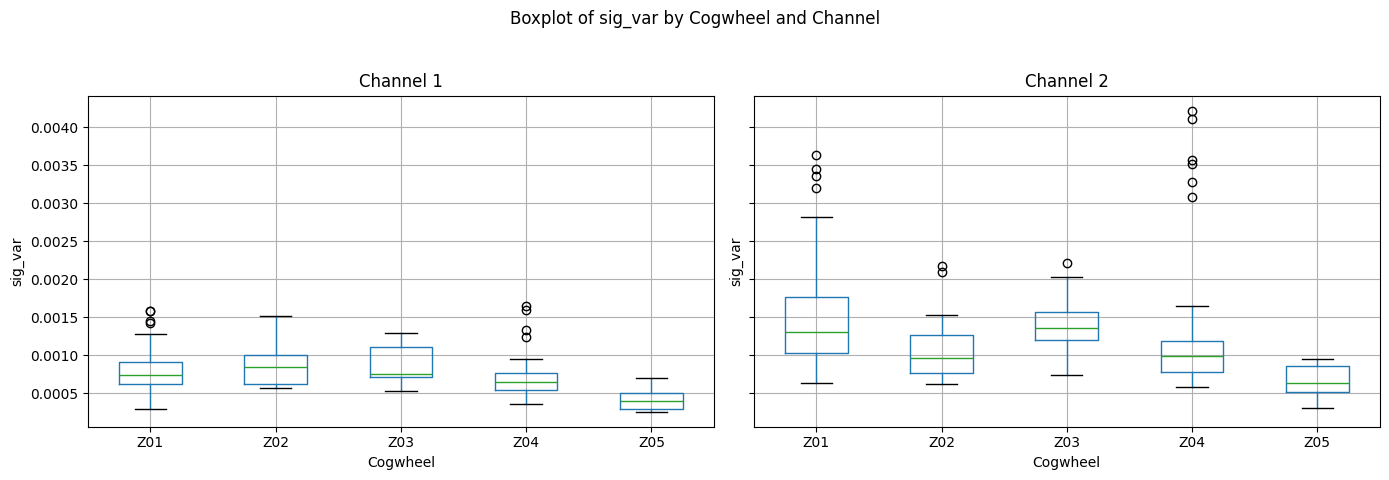

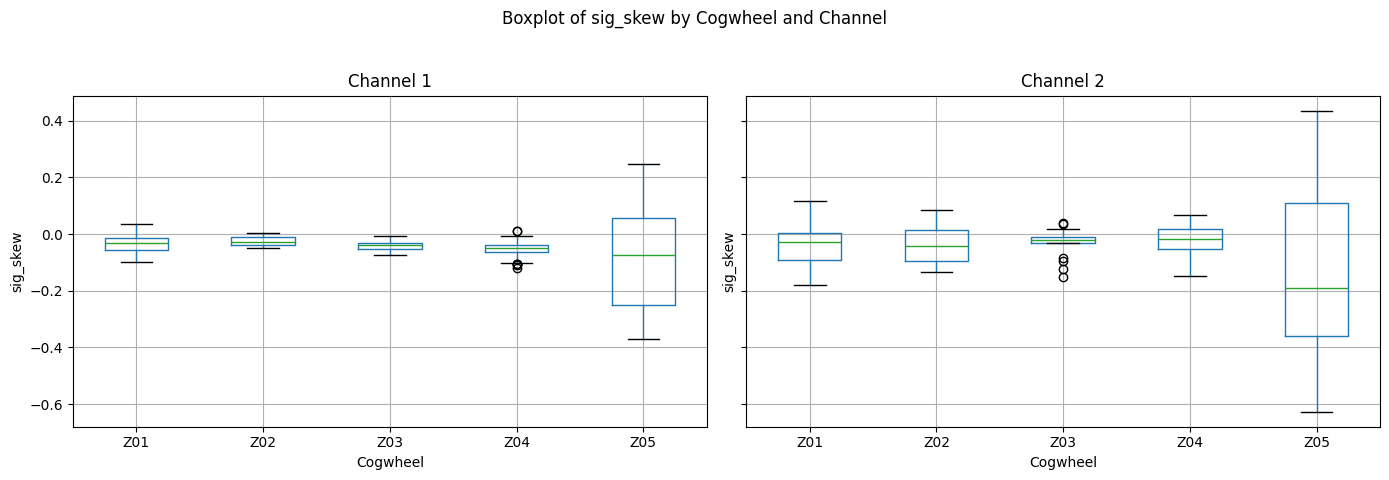

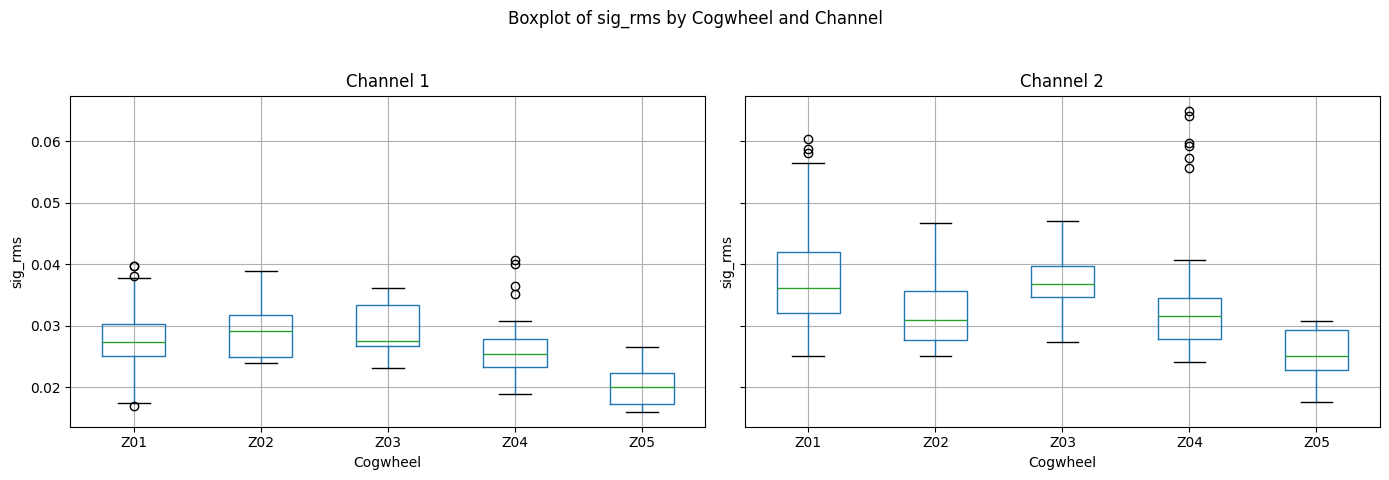

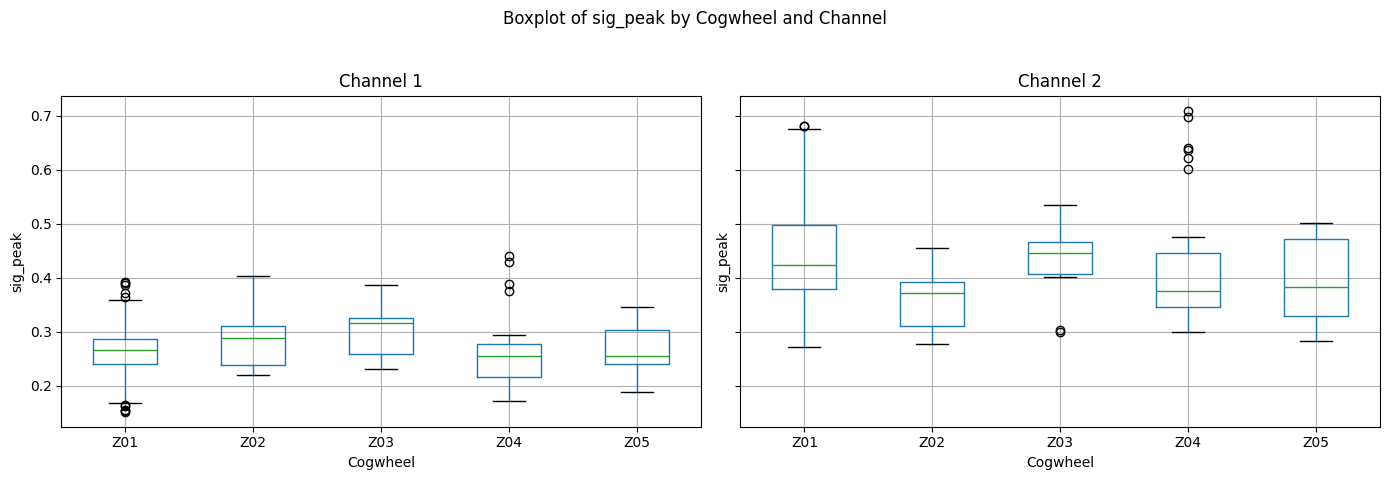

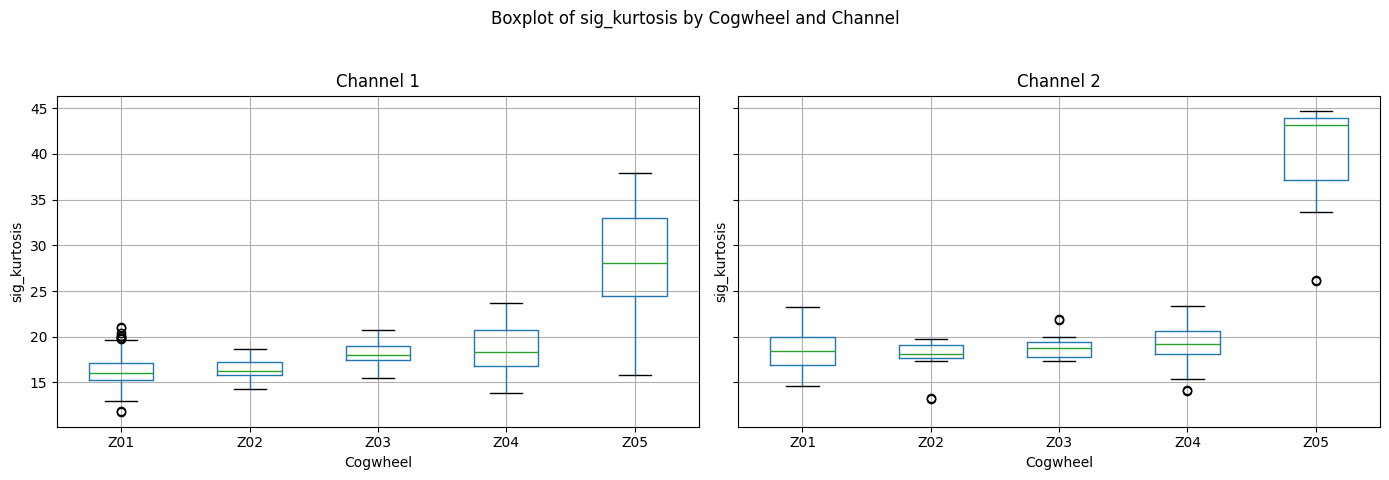

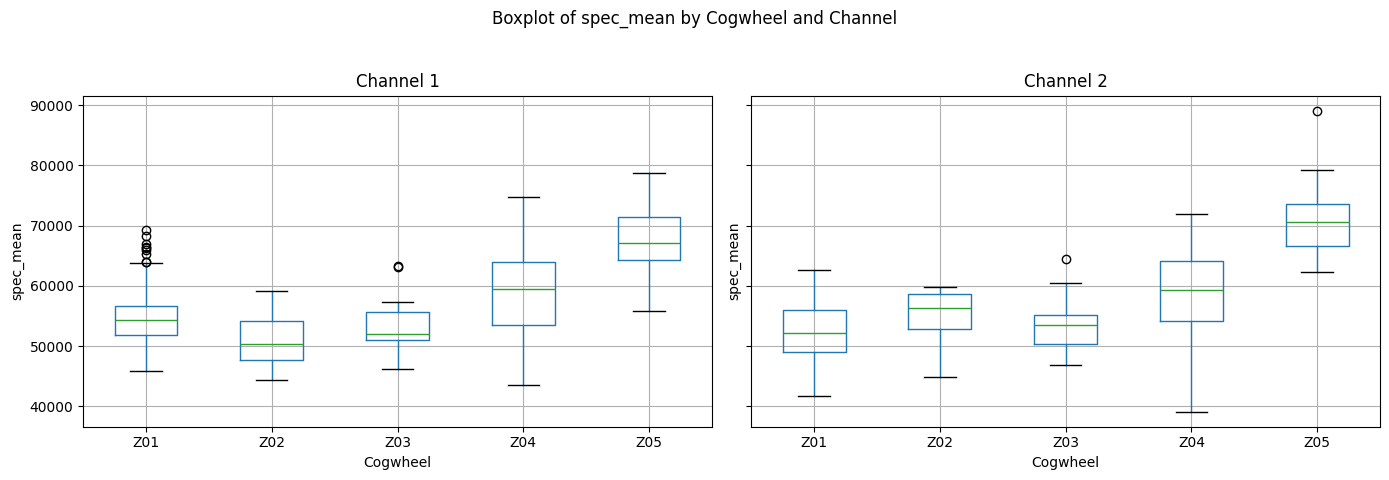

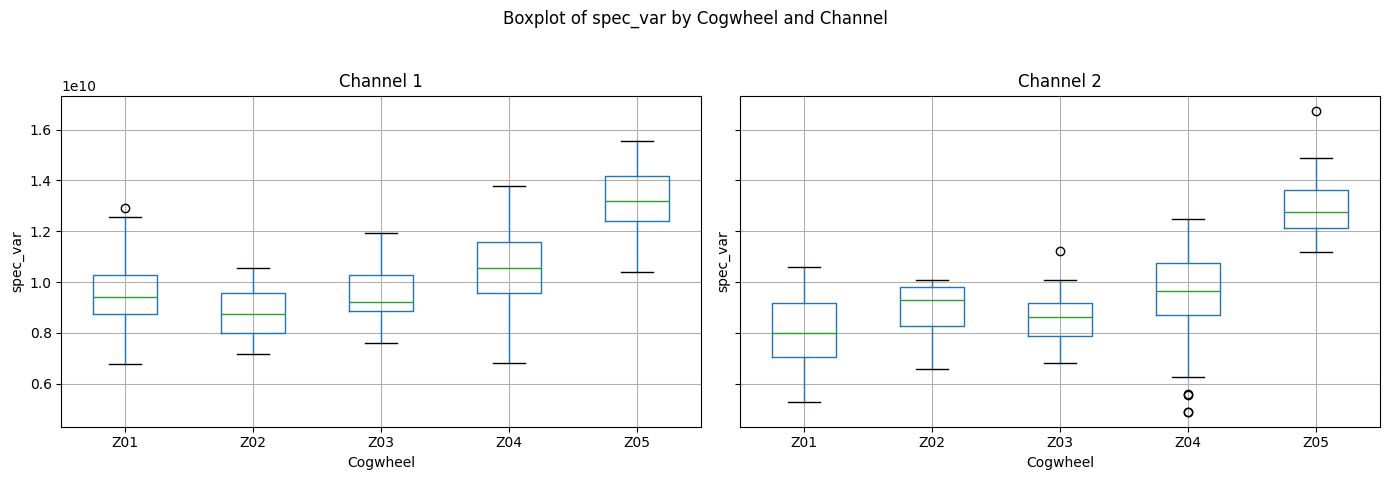

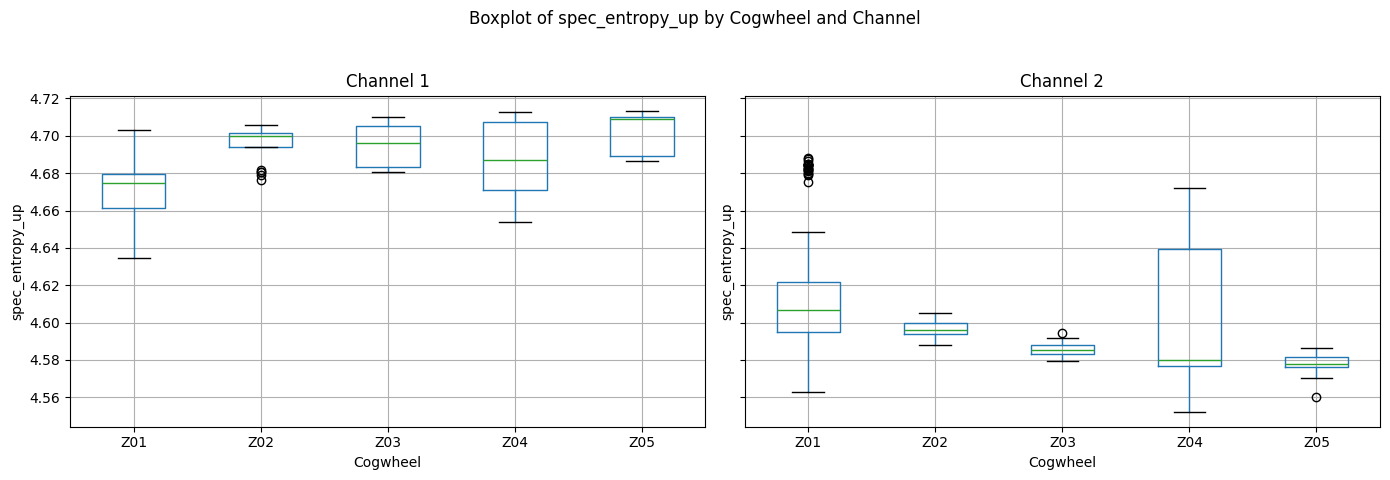

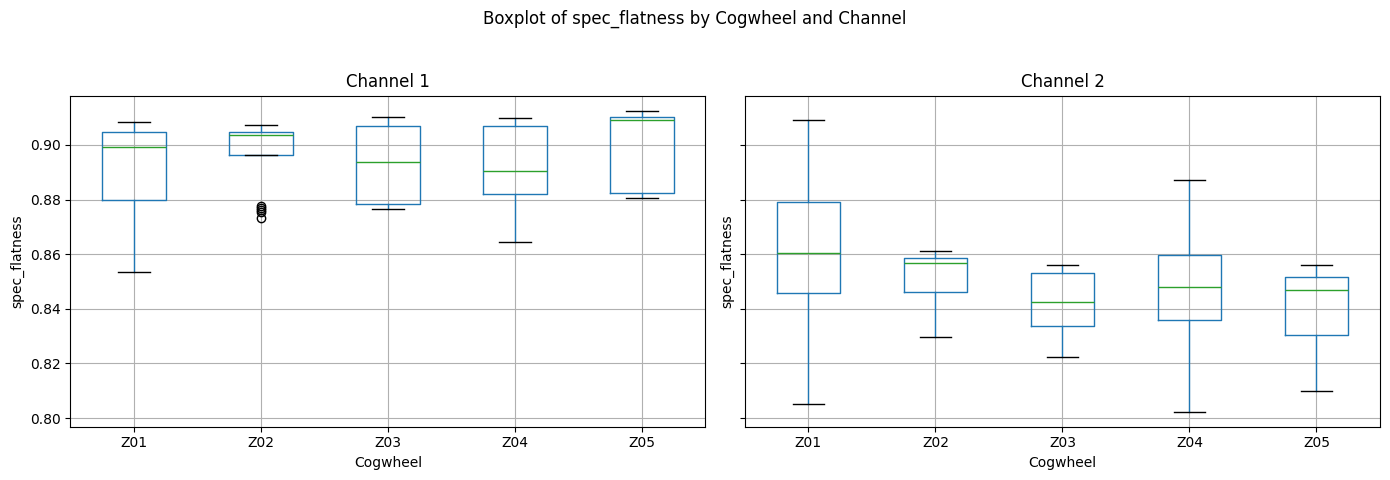

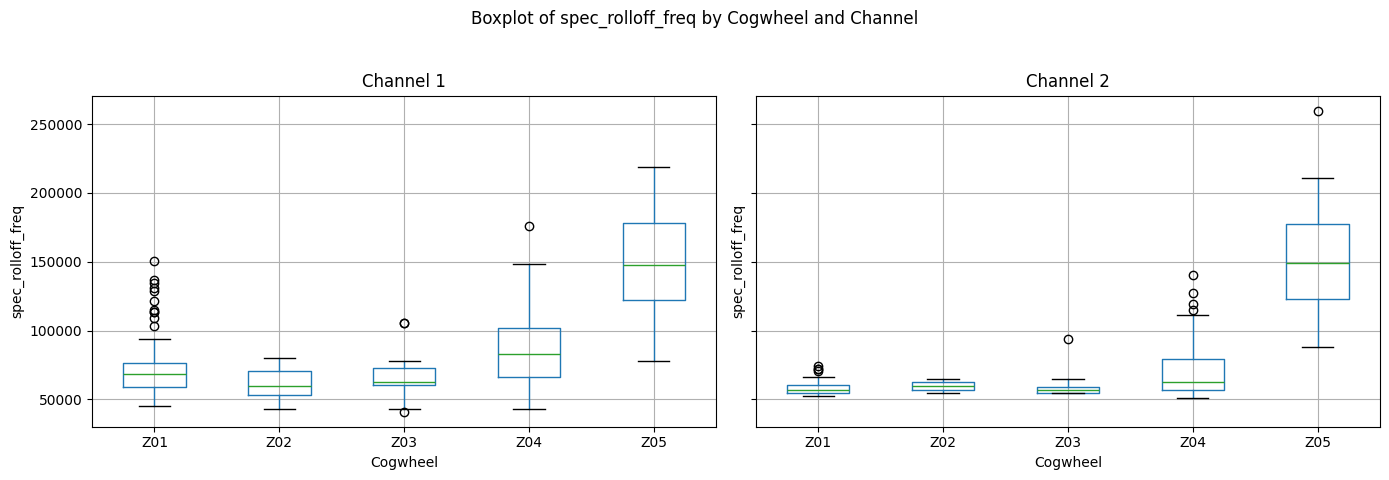

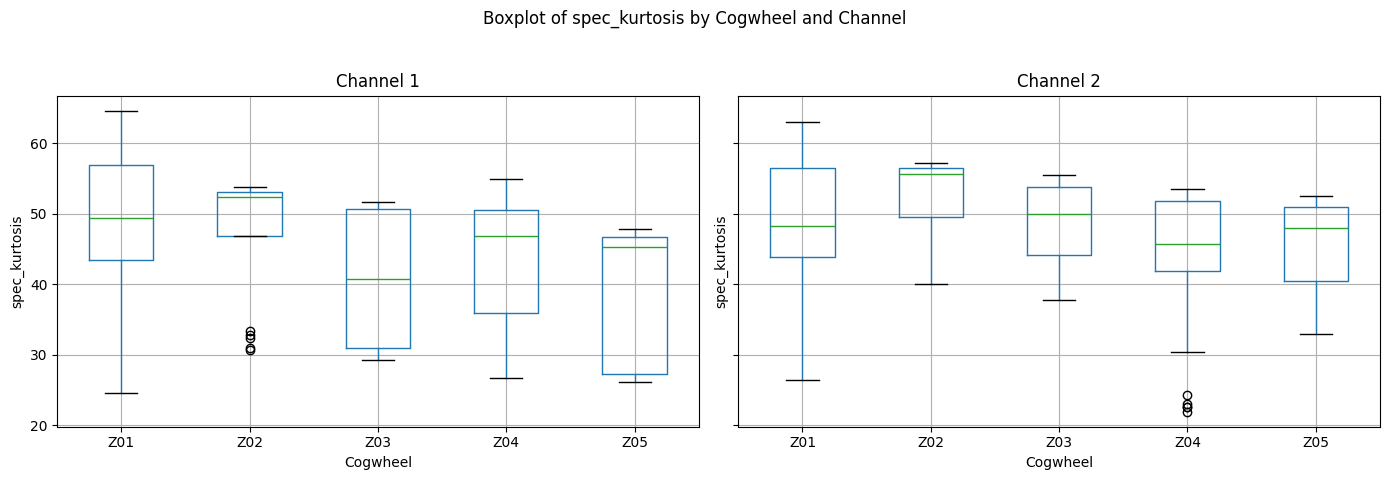

In [14]:
feature_cols = [
    'sig_mean', 'sig_var', 'sig_skew', 'sig_rms', 'sig_peak', 'sig_kurtosis',
    'spec_mean', 'spec_var', 'spec_entropy_up', 'spec_flatness', 
    'spec_rolloff_freq', 'spec_kurtosis'
]

for c in feature_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for idx, channel in enumerate(sorted(df['channel'].unique())):
        df_channel = df[df['channel'] == channel]
        df_channel.boxplot(column=c, by='spec', ax=axes[idx])
        axes[idx].set_title(f'Channel {channel}')
        axes[idx].set_xlabel("Cogwheel")
        axes[idx].set_ylabel(c)
    plt.suptitle(f'Boxplot of {c} by Cogwheel and Channel')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



4.2

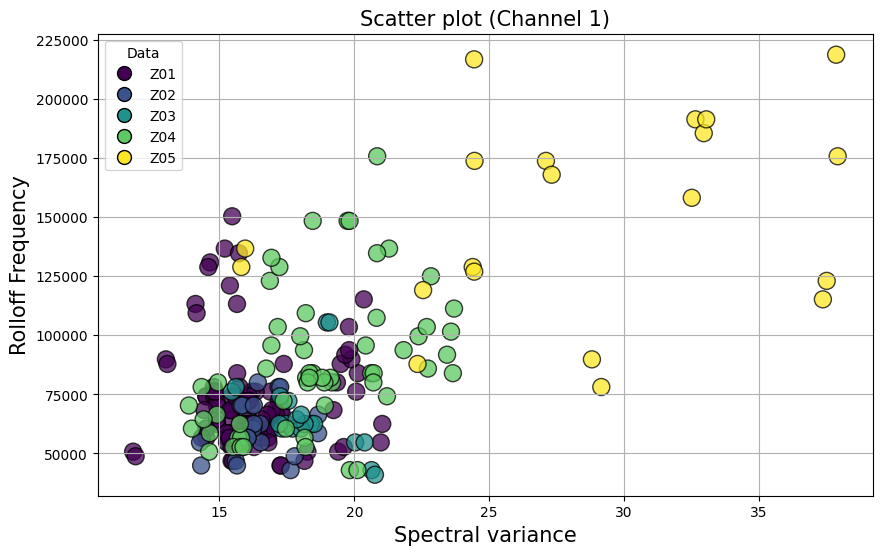

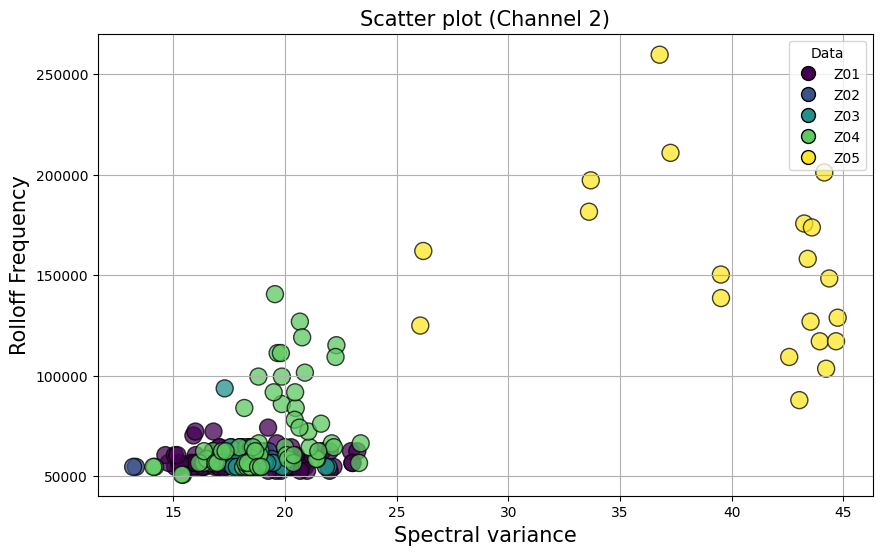

In [15]:
farben = df['spec'].apply(lambda x: int(x[-1]))  # z.B. Werte 1-5
klassen = sorted(farben.unique())                # [1, 2, 3, 4, 5]
labels = [f"Z0{i}" for i in klassen]             # ['Z01', 'Z02', ..., 'Z05']

for channel in sorted(df['channel'].unique()):
    df_channel = df[df['channel'] == channel]
    farben = df_channel['spec'].apply(lambda x: int(x[-1]))
    klassen = sorted(farben.unique())
    labels = [f"Z0{i}" for i in klassen]

    plt.figure(figsize=(10,6))
    scatter = plt.scatter(
        df_channel['sig_kurtosis'],
        df_channel['spec_rolloff_freq'],
        c=farben,
        edgecolors='k',
        alpha=0.75,
        s=150
    )
    plt.grid(True)
    plt.title(f"Scatter plot (Channel {channel})", fontsize=15)
    plt.xlabel("Spectral variance", fontsize=15)
    plt.ylabel("Rolloff Frequency", fontsize=15)
    handles = [
        plt.Line2D([], [], marker='o', color='w',
                   markerfacecolor=scatter.cmap(scatter.norm(k)),
                   markeredgecolor='k', markersize=10, label=label)
        for k, label in zip(klassen, labels)
    ]
    plt.legend(handles=handles, labels=labels, title="Data")
    plt.show()

4.3

Korrelationsmatrix für Channel 1


C:\Users\elmo.geck\AppData\Local\Temp\ipykernel_5832\348440905.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet', 30)


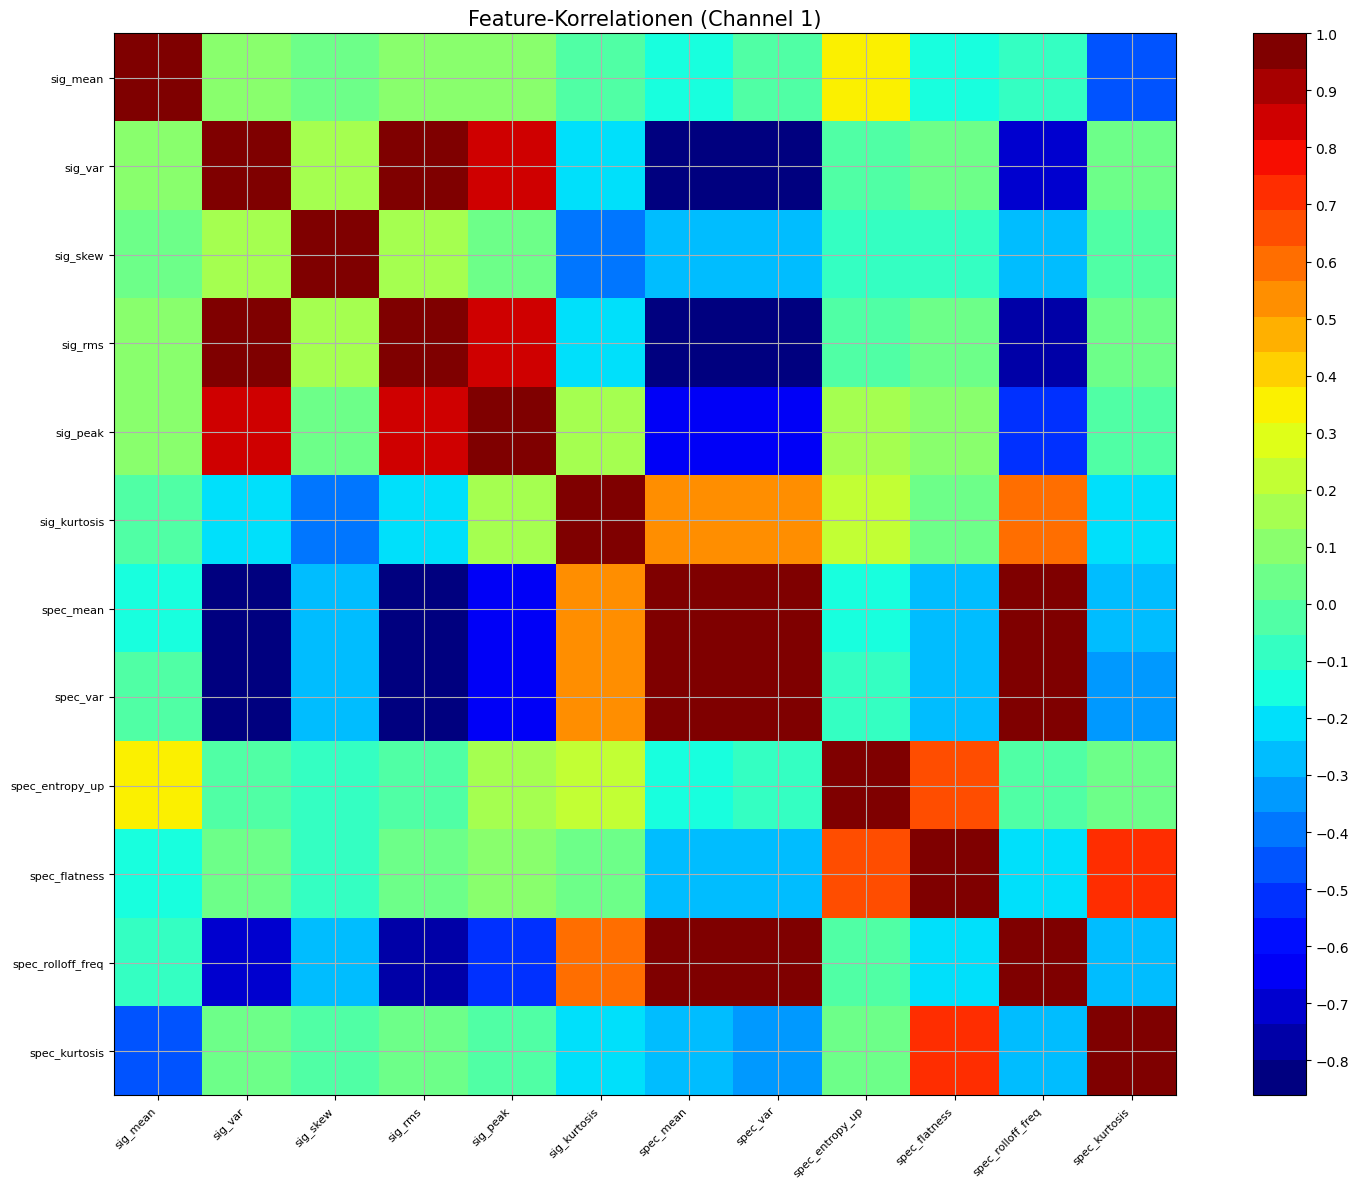

Korrelationsmatrix für Channel 2


C:\Users\elmo.geck\AppData\Local\Temp\ipykernel_5832\348440905.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet', 30)


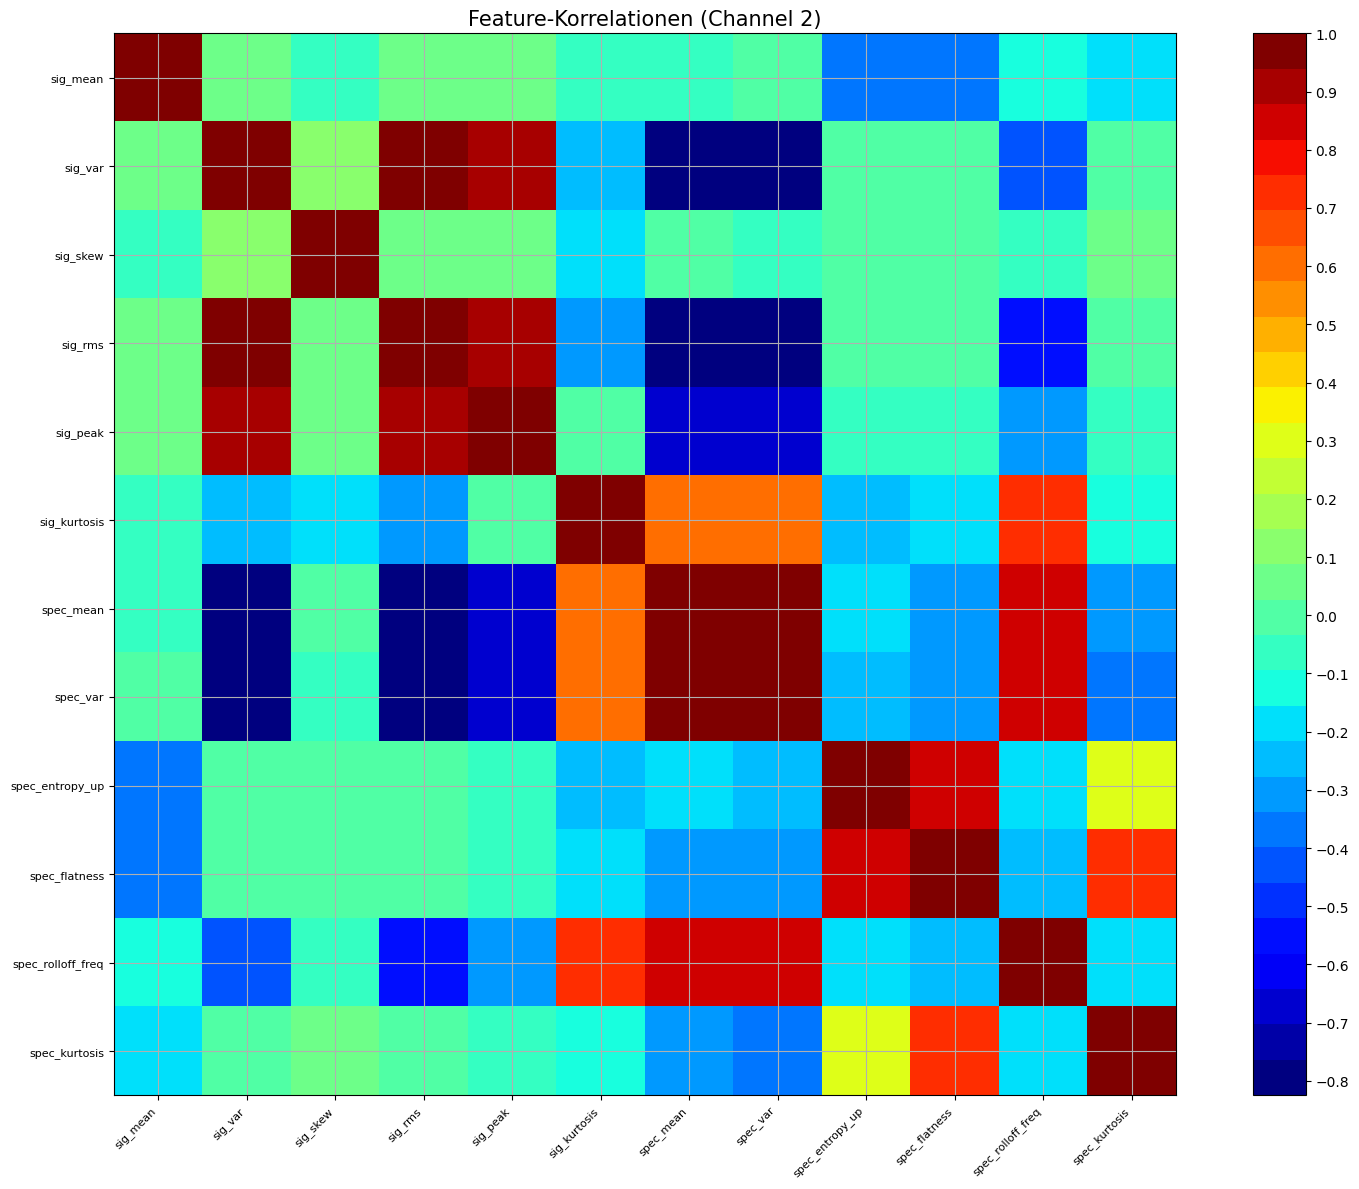

In [16]:
def correlation_matrix(df_features, channel):
    fig = plt.figure(figsize=(16,12))
    ax1 = fig.add_subplot(111)
    cmap = cm.get_cmap('jet', 30)
    cax = ax1.imshow(df_features.corr(), interpolation="nearest", cmap=cmap)
    ax1.grid(True)
    plt.title(f'Feature-Korrelationen (Channel {channel})', fontsize=15)
    labels = df_features.columns
    ax1.set_xticks(np.arange(len(labels)))
    ax1.set_yticks(np.arange(len(labels)))
    ax1.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')
    ax1.set_yticklabels(labels, fontsize=8)
    fig.colorbar(cax, ticks=[0.1*i for i in range(-11,11)])
    plt.tight_layout()
    plt.show()

# Jetzt für jeden Channel die Matrix plotten:
for channel in sorted(df['channel'].unique()):
    print(f"Korrelationsmatrix für Channel {channel}")
    just_features = df[df['channel'] == channel][[
        'sig_mean','sig_var','sig_skew', 'sig_rms', 'sig_peak', 'sig_kurtosis', 
        'spec_mean', 'spec_var', 'spec_entropy_up', 'spec_flatness', 'spec_rolloff_freq', 'spec_kurtosis'
    ]]
    correlation_matrix(just_features, channel)

## 5. Feature overview using Seaborn

5.1 

### ATTENTION! Very long load times!

Pairplot für Channel 1


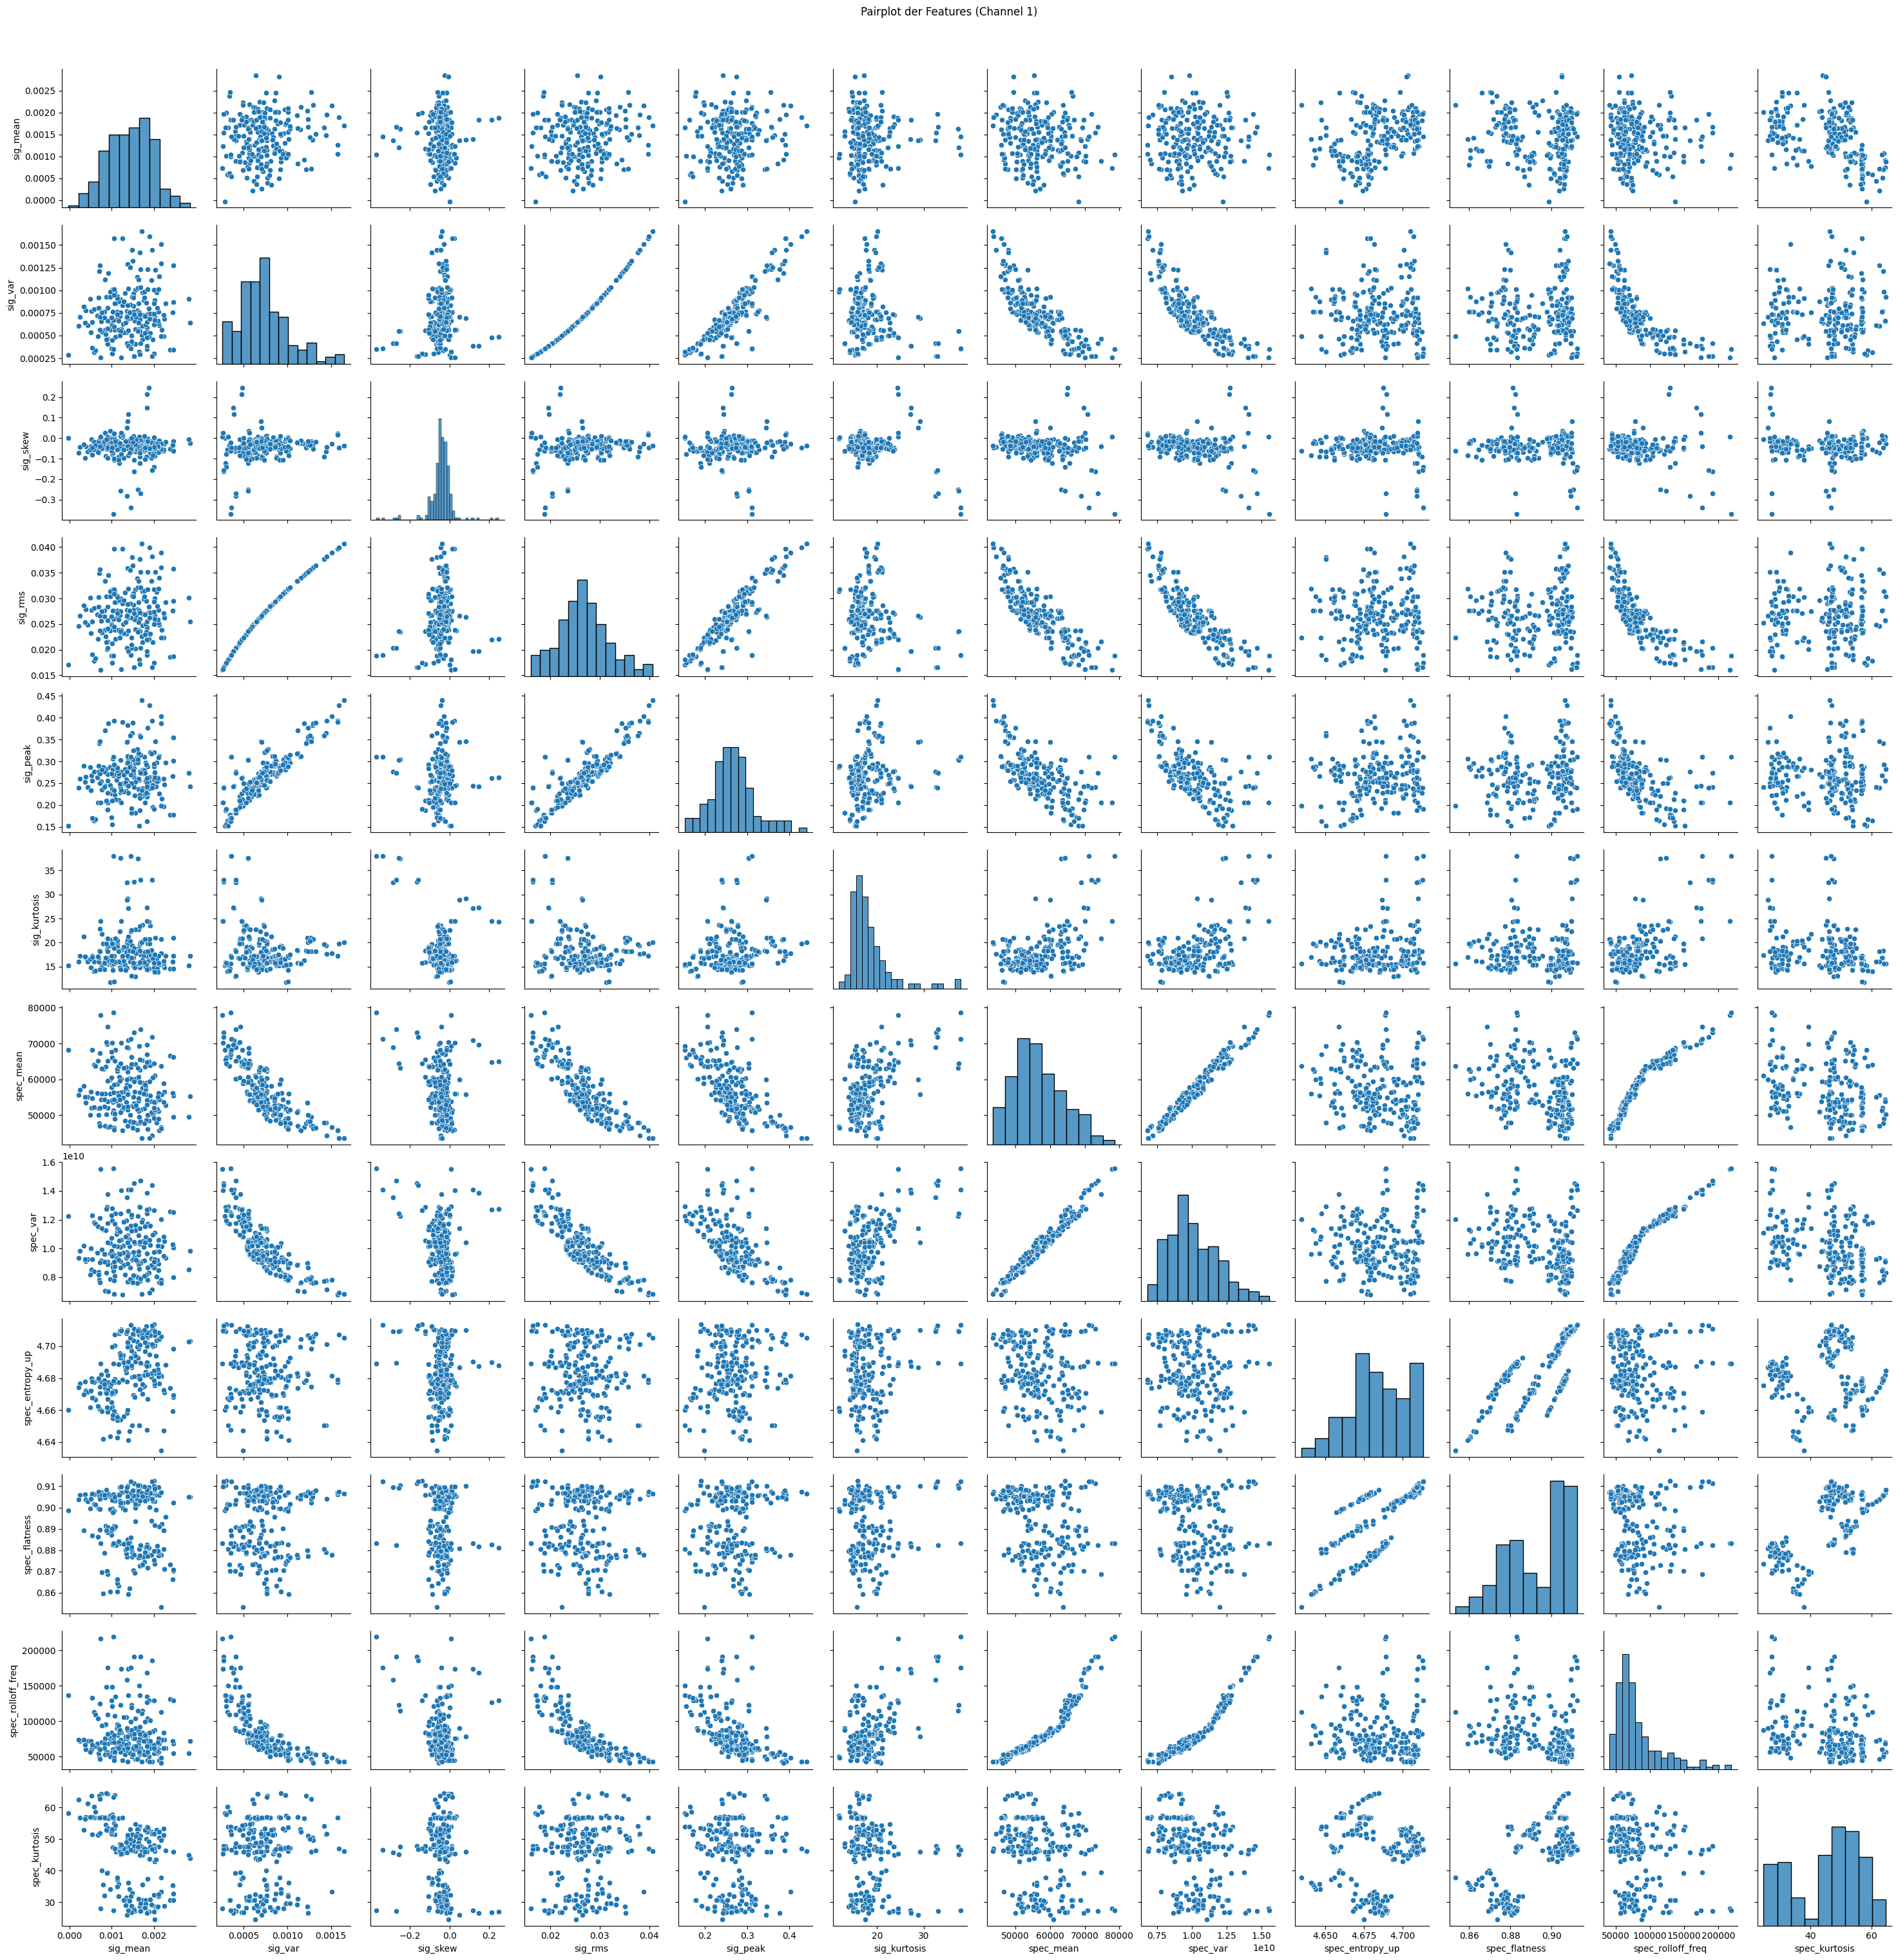

Pairplot für Channel 2


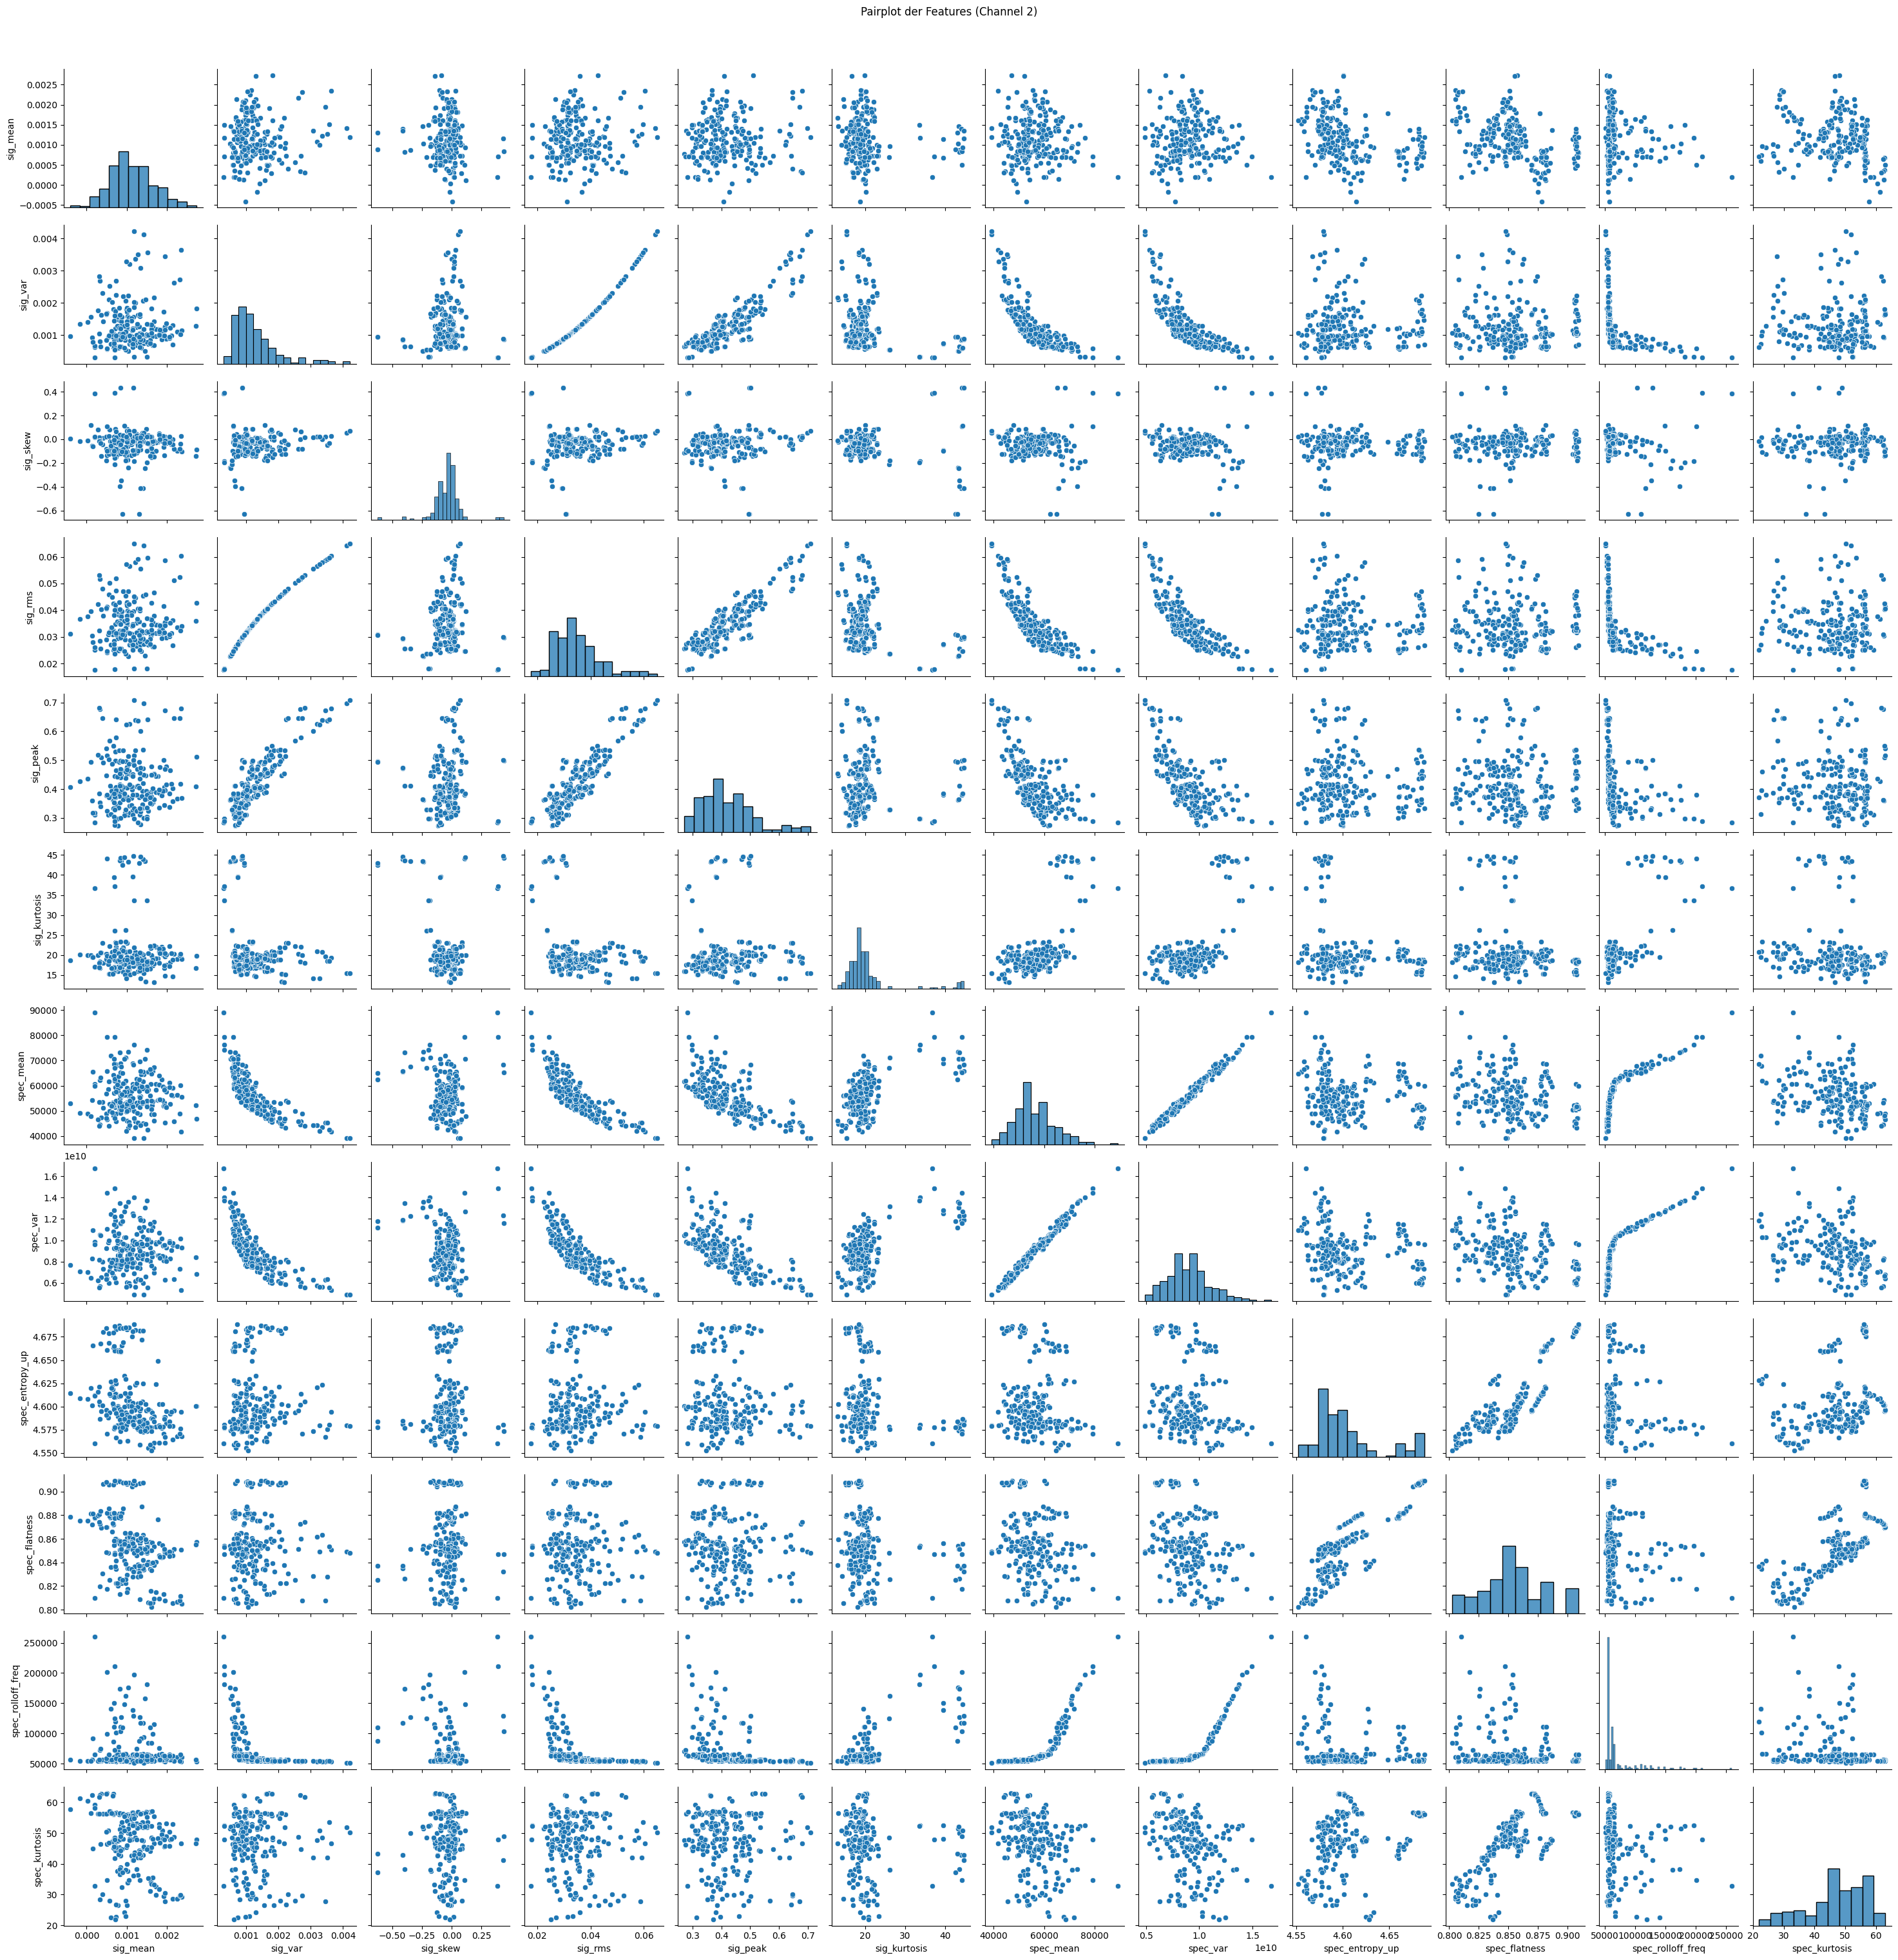

In [17]:
feature_cols = [
    'sig_mean', 'sig_var', 'sig_skew', 'sig_rms', 'sig_peak', 'sig_kurtosis',
    'spec_mean', 'spec_var', 'spec_entropy_up', 'spec_flatness', 
    'spec_rolloff_freq', 'spec_kurtosis'
]

for channel in sorted(df['channel'].unique()):
    print(f"Pairplot für Channel {channel}")
    just_features = df[df['channel'] == channel][feature_cols]
    sns.pairplot(just_features)
    plt.suptitle(f"Pairplot der Features (Channel {channel})", y=1.02)
    plt.show()


5.2


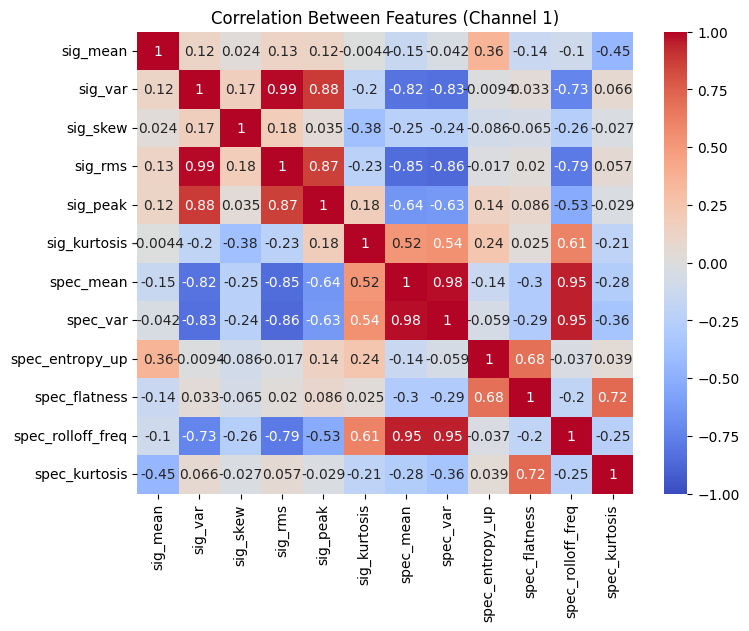

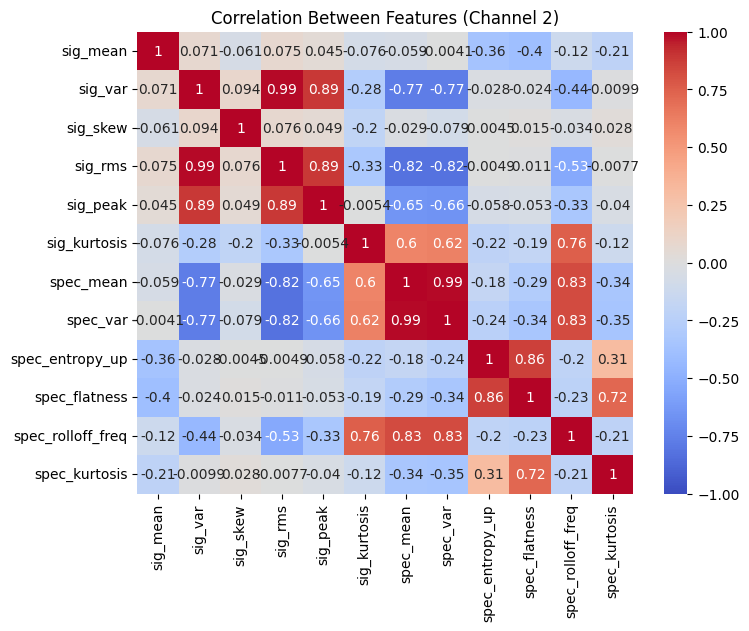

In [18]:
for channel in sorted(df['channel'].unique()):
    just_features = df[df['channel'] == channel][feature_cols]
    plt.figure(figsize=(8, 6))
    sns.heatmap(just_features.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"Correlation Between Features (Channel {channel})")
    plt.show()


5.3

In [19]:
for channel in sorted(df['channel'].unique()):
    just_features = df[df['channel'] == channel][feature_cols]
    scaler = StandardScaler()
    X = scaler.fit_transform(just_features)
    dfx = pd.DataFrame(data=X, columns=just_features.columns)
    print(f"Skalierte Werte für Channel {channel}:")
    print(dfx.head(10))

Skalierte Werte für Channel 1:
   sig_mean   sig_var  sig_skew   sig_rms  sig_peak  sig_kurtosis  spec_mean  \
0  0.168467  0.311092  0.358983  0.401498  0.103540     -0.304927  -0.226851   
1 -0.348686  0.358022  0.739297  0.444029  0.150453     -0.309502  -0.715761   
2 -0.876226 -0.633719  1.256762 -0.603049 -0.403699     -0.428486  -0.092486   
3 -1.119169 -0.612733  1.114132 -0.579520 -0.431847     -0.462671  -0.104428   
4 -1.300166 -0.289030  0.626661 -0.217068 -0.234815     -0.599035  -0.337505   
5 -1.008902 -0.269569  0.819522 -0.195084 -0.206668     -0.629929  -0.414671   
6  1.117307 -0.370274  0.587789 -0.291894 -0.497524     -0.191842   0.597122   
7  2.709882 -0.349992  0.274449 -0.253747 -0.469377     -0.233091  -0.202663   
8 -0.125501  0.111059  0.520021  0.203503  0.544516      0.420697   0.006355   
9 -0.007650  0.089273  0.534344  0.182305  0.563281      0.434245   0.484148   

   spec_var  spec_entropy_up  spec_flatness  spec_rolloff_freq  spec_kurtosis  
0 -0.204

5.4

In [20]:
for channel in sorted(df['channel'].unique()):
    just_features = df[df['channel'] == channel][feature_cols]
    scaler = StandardScaler()
    X = scaler.fit_transform(just_features)
    dfx = pd.DataFrame(data=X, columns=just_features.columns)
    print(f"Statistik für Channel {channel}:")
    print(dfx.describe())

Statistik für Channel 1:
           sig_mean       sig_var      sig_skew       sig_rms      sig_peak  \
count  2.200000e+02  2.200000e+02  2.200000e+02  2.200000e+02  2.200000e+02   
mean   2.422305e-16 -5.652044e-17  2.422305e-17 -1.614870e-16  1.009294e-16   
std    1.002281e+00  1.002281e+00  1.002281e+00  1.002281e+00  1.002281e+00   
min   -2.775783e+00 -1.726463e+00 -5.243006e+00 -2.130334e+00 -2.205719e+00   
25%   -7.364373e-01 -6.630631e-01 -2.530194e-01 -6.345527e-01 -5.983855e-01   
50%    4.930885e-02 -1.212180e-01  5.305286e-02 -3.408068e-02 -6.593049e-02   
75%    7.567439e-01  5.046788e-01  4.255324e-01  5.852575e-01  4.647653e-01   
max    2.709882e+00  3.283058e+00  4.660903e+00  2.778453e+00  3.341664e+00   

       sig_kurtosis     spec_mean      spec_var  spec_entropy_up  \
count  2.200000e+02  2.200000e+02  2.200000e+02     2.200000e+02   
mean  -4.198662e-16 -3.391227e-16  1.614870e-17     2.486900e-14   
std    1.002281e+00  1.002281e+00  1.002281e+00     1.00228

## 6. PCA

6.1


In [21]:
from sklearn.decomposition import PCA

for channel in sorted(df['channel'].unique()):
    print(f"PCA für Channel {channel}")
    just_features = df[df['channel'] == channel][feature_cols]
    scaler = StandardScaler()
    X = scaler.fit_transform(just_features)
    pca = PCA(n_components=None)
    pca.fit(X)

PCA für Channel 1
PCA für Channel 2


6.2


Explained Variance Ratio (Channel 1)


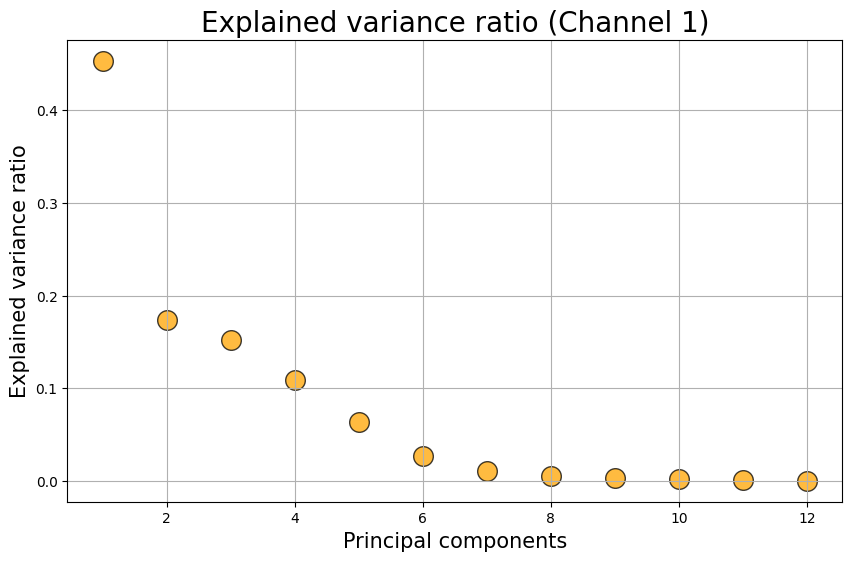

Explained Variance Ratio (Channel 2)


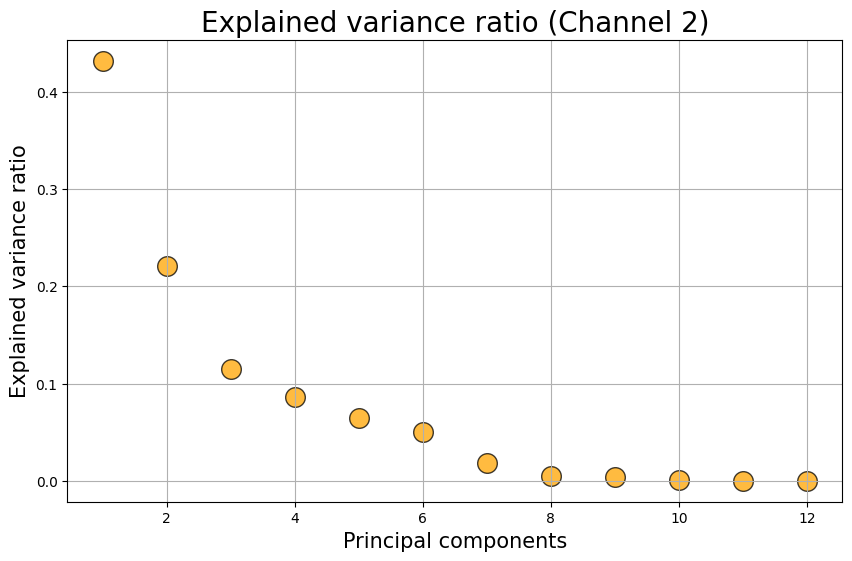

In [22]:
for channel in sorted(df['channel'].unique()):
    print(f"Explained Variance Ratio (Channel {channel})")
    just_features = df[df['channel'] == channel][feature_cols]
    scaler = StandardScaler()
    X = scaler.fit_transform(just_features)
    pca = PCA(n_components=None)
    pca.fit(X)
    plt.figure(figsize=(10,6))
    plt.scatter(x=[i+1 for i in range(len(pca.explained_variance_ratio_))],
                y=pca.explained_variance_ratio_,
                s=200, alpha=0.75, c='orange', edgecolor='k')
    plt.grid(True)
    plt.title(f"Explained variance ratio (Channel {channel})", fontsize=20)
    plt.xlabel("Principal components", fontsize=15)
    plt.ylabel("Explained variance ratio", fontsize=15)
    plt.show()

6.3


In [23]:
for channel in sorted(df['channel'].unique()):
    just_features = df[df['channel'] == channel][feature_cols]
    scaler = StandardScaler()
    X = scaler.fit_transform(just_features)
    pca = PCA(n_components=None)
    X_pca = pca.fit_transform(X)
    dfx_trans = pd.DataFrame(data=X_pca)
    print(f"PCA-transformierte Daten (Channel {channel}):")
    print(dfx_trans.head(10))

PCA-transformierte Daten (Channel 1):
         0         1         2         3         4         5         6   \
0 -0.295696 -2.394090 -0.388966  0.124247 -0.044693 -0.594262 -0.116024   
1 -1.385775  0.432525 -0.191028  0.369730  0.576998 -0.477775 -0.053239   
2  0.021793  1.355178 -1.599449  0.162189  0.966555  0.270646 -0.401020   
3  0.022268  1.413361 -1.638749  0.012175  0.896187  0.043587 -0.354844   
4 -0.647135  2.012839 -1.505251 -0.356941  0.519882  0.105615 -0.103538   
5 -0.785979  1.889842 -1.489126 -0.121676  0.580450  0.306824 -0.155634   
6  1.185565 -2.344133 -0.018765  1.223996  0.029796 -0.195554 -0.142066   
7 -0.191180  0.322690  1.208330  2.591350 -0.527106  1.073763 -0.160613   
8 -0.305151 -1.000411 -0.626139 -0.872028  0.439148  0.691102 -0.557047   
9  0.502175 -2.882311 -0.767314 -1.015365  0.372579  0.402877 -0.536731   

         7         8         9         10        11  
0 -0.032333 -0.285079 -0.061821 -0.072234 -0.001378  
1 -0.107340 -0.255286 -0.042

## 7. Visualization

7.1

PCA-Scatter für Channel 1


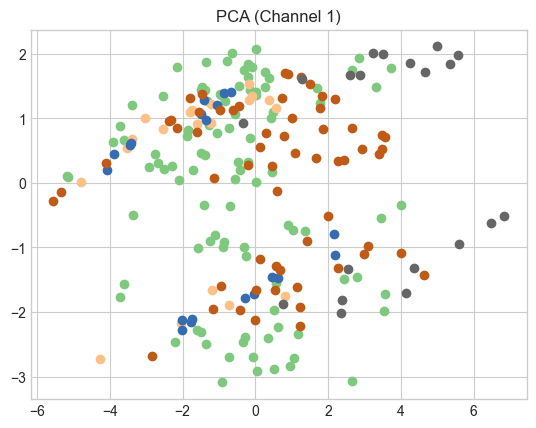

PCA-Scatter für Channel 2


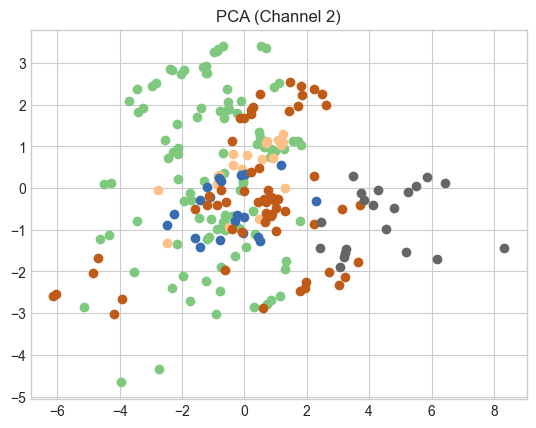

In [24]:
def do_plot(X_fit, title=None, labels=None):
    dimension = X_fit.shape[1]
    label_types = sorted(list(set(labels)))
    num_labels = len(label_types)
    colors = plt.cm.Accent(np.linspace(0, 1, num_labels))
    with plt.style.context(plt_style):
        fig = plt.figure()
        if dimension == 2:
            ax = fig.add_subplot(111)
            for lab, col in zip(label_types, colors):
                ax.scatter(X_fit[labels==lab, 0],
                           X_fit[labels==lab, 1],
                           color=col)
        elif dimension == 3:
            ax = fig.add_subplot(111, projection='3d')
            for lab, col in zip(label_types, colors):
                ax.scatter(X_fit[labels==lab, 0],
                           X_fit[labels==lab, 1],
                           X_fit[labels==lab, 2],
                           color=col)
        else:
            raise Exception('Unknown dimension: %d' % dimension)
        plt.title(title)
        plt.show()

plt_style = 'seaborn-v0_8-whitegrid'

for channel in sorted(df['channel'].unique()):
    print(f"PCA-Scatter für Channel {channel}")
    just_features = df[df['channel'] == channel][feature_cols]
    scaler = StandardScaler()
    X = scaler.fit_transform(just_features)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    do_plot(X_pca, f'PCA (Channel {channel})', df[df['channel'] == channel]['spec'].values)

7.2

MDS-Scatter für Channel 1


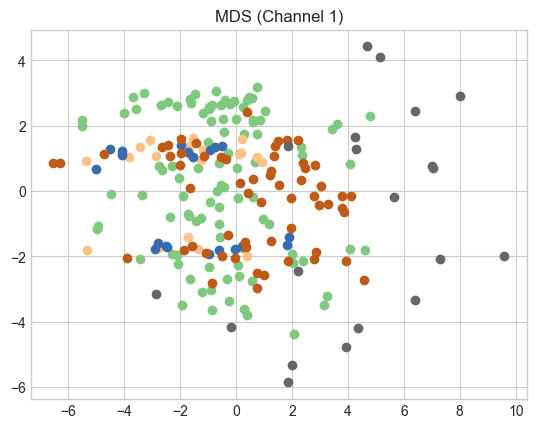

MDS-Scatter für Channel 2


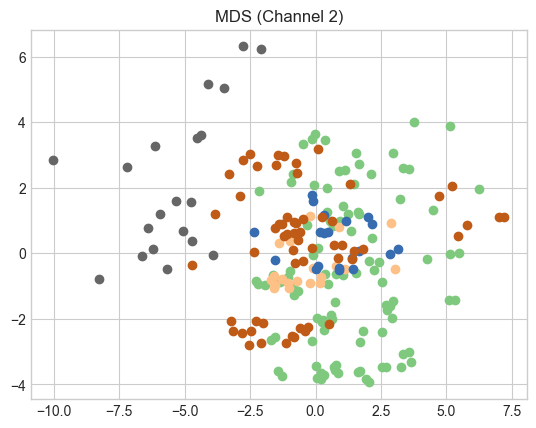

In [25]:
for channel in sorted(df['channel'].unique()):
    print(f"MDS-Scatter für Channel {channel}")
    just_features = df[df['channel'] == channel][feature_cols]
    scaler = StandardScaler()
    X = scaler.fit_transform(just_features)
    mds = MDS(n_components=2, random_state=42)
    X_mds = mds.fit_transform(X)
    do_plot(X_mds, f'MDS (Channel {channel})', df[df['channel'] == channel]['spec'].values)


7.3

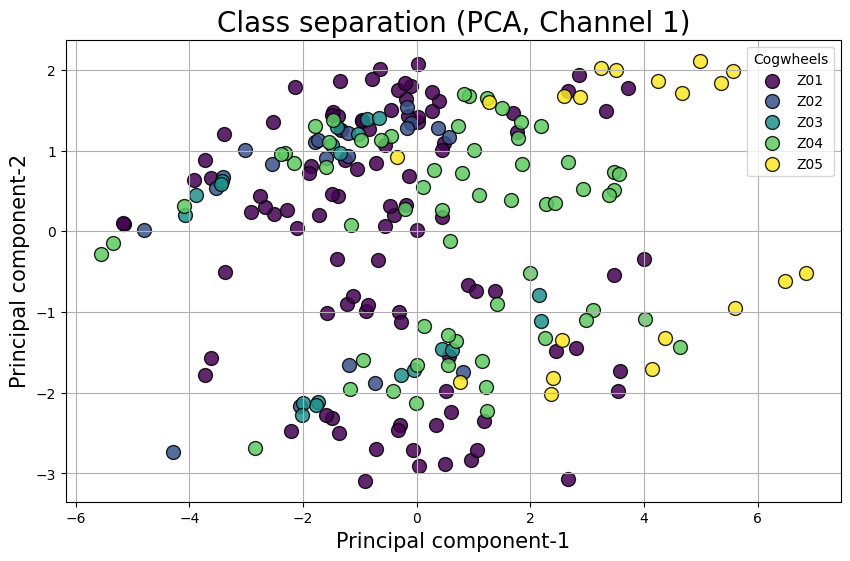

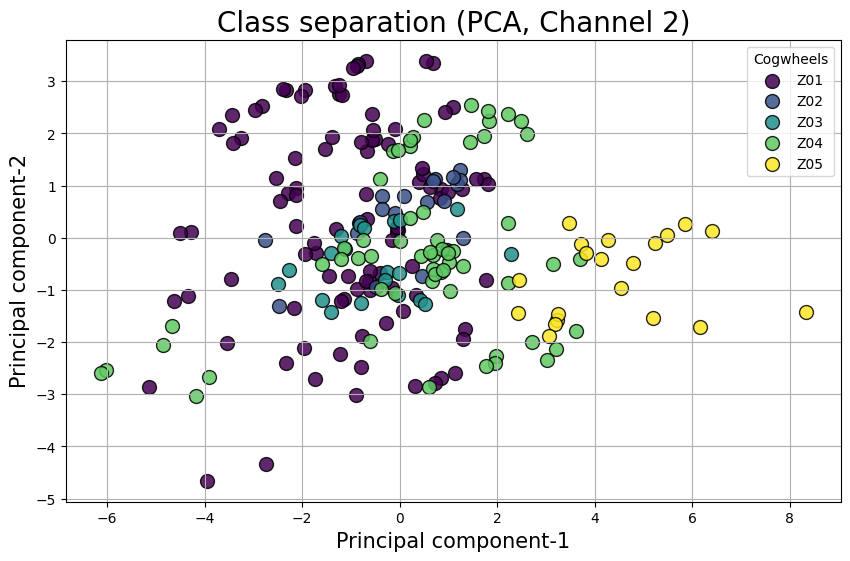

In [26]:
# Extract the class labels from the 'spec' column
class_labels = sorted(df['spec'].apply(lambda x: int(x[-1])).unique())

# Define a colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(class_labels)))

# Plot each class separately
for channel in sorted(df['channel'].unique()):
    just_features = df[df['channel'] == channel][feature_cols]
    scaler = StandardScaler()
    X = scaler.fit_transform(just_features)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    class_labels = sorted(df[df['channel'] == channel]['spec'].apply(lambda x: int(x[-1])).unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(class_labels)))
    plt.figure(figsize=(10, 6))
    for label, color in zip(class_labels, colors):
        idx = df[df['channel'] == channel]['spec'].apply(lambda x: int(x[-1])) == label
        plt.scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            label=f"Z0{label}",
            edgecolors='k',
            alpha=0.85,
            s=100,
            color=color)
    plt.grid(True)
    plt.title(f"Class separation (PCA, Channel {channel})", fontsize=20)
    plt.xlabel("Principal component-1", fontsize=15)
    plt.ylabel("Principal component-2", fontsize=15)
    plt.legend(title="Cogwheels")
    plt.show()

7.4

<Figure size 1000x600 with 0 Axes>

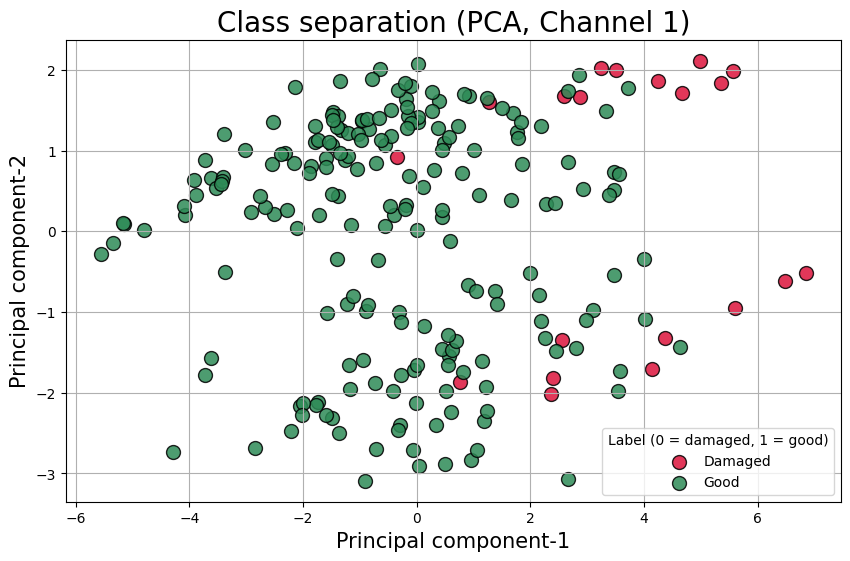

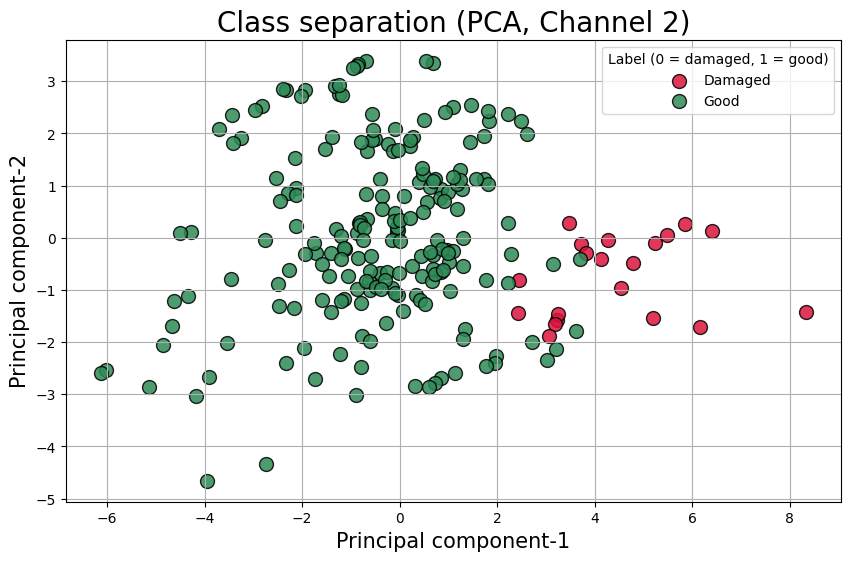

In [27]:
# Binary labels: 0 = damaged (Z05), 1 = good (Z01 to Z04)
binary_labels = df['spec'].apply(lambda x: 0 if x == 'Z05' else 1)

# Set up colors and labels
colors = {0: 'crimson', 1: 'seagreen'}
label_names = {0: 'Damaged', 1: 'Good'}

plt.figure(figsize=(10, 6))

# Plot each binary class
for channel in sorted(df['channel'].unique()):
    just_features = df[df['channel'] == channel][feature_cols]
    scaler = StandardScaler()
    X = scaler.fit_transform(just_features)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    binary_labels = df[df['channel'] == channel]['spec'].apply(lambda x: 0 if x == 'Z05' else 1)
    colors = {0: 'crimson', 1: 'seagreen'}
    label_names = {0: 'Damaged', 1: 'Good'}
    plt.figure(figsize=(10, 6))
    for binary_class in [0, 1]:
        idx = binary_labels == binary_class
        plt.scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            label=label_names[binary_class],
            color=colors[binary_class],
            edgecolors='k',
            alpha=0.85,
            s=100
        )
    plt.grid(True)
    plt.title(f"Class separation (PCA, Channel {channel})", fontsize=20)
    plt.xlabel("Principal component-1", fontsize=15)
    plt.ylabel("Principal component-2", fontsize=15)
    plt.legend(title="Label (0 = damaged, 1 = good)")
    plt.show()

# 8. MLP-Klassifikation und Evaluation

# Aufteilung in Trainings-, Entwicklungs- und Testdaten

In [100]:
import numpy as np

df['sID'] = df['sID'].astype(str).str.strip()
channels = df['sID'].unique()

for channel in channels:
    print(f"\n=== Channel {channel} ===")
    df_channel = df[df['sID'] == channel].copy()

    # Label: 0 = Z05 (defekt), 1 = alles andere (gut)
    df_channel['label'] = (df_channel['spec'] != 'Z05').astype(int)

    # Features auswählen (z.B. nur numerische)
    feature_cols = [c for c in df_channel.columns if c not in ['spec', 'label', 'sID']]
    X = df_channel[feature_cols].select_dtypes(include=[np.number])
    y = df_channel['label']

    # 1. Split: 60% Train, 40% Temp (Dev+Test), stratifiziert!
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=0.6, stratify=y, random_state=42
    )

    # 2. Split: 50/50 Dev und Test, stratifiziert!
    X_dev, X_test, y_dev, y_test = train_test_split(
        X_temp, y_temp, train_size=0.5, stratify=y_temp, random_state=42
    )

    # Skalieren
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_dev_scaled = scaler.transform(X_dev)
    X_test_scaled = scaler.transform(X_test)

    # Debug-Ausgaben
    print("Train labels:", np.bincount(y_train))
    print("Dev labels: ", np.bincount(y_dev))
    print("Test labels: ", np.bincount(y_test))
    print(f"Train size: {len(y_train)}, Dev size: {len(y_dev)}, Test size: {len(y_test)}")



=== Channel Ch1 ===
Train labels: [ 12 120]
Dev labels:  [ 4 40]
Test labels:  [ 4 40]
Train size: 132, Dev size: 44, Test size: 44

=== Channel Ch2 ===
Train labels: [ 12 120]
Dev labels:  [ 4 40]
Test labels:  [ 4 40]
Train size: 132, Dev size: 44, Test size: 44


8.1 Hyperparameter

In [101]:

df['sID'] = df['sID'].astype(str).str.strip()
channels = df['sID'].unique()

best_params_dict = {}

for channel in channels:
    print(f"\n=== Channel {channel} ===")
    df_channel = df[df['sID'] == channel].copy()

    # Label: 0 = Z05 (defekt), 1 = alles andere (gut)
    df_channel['label'] = (df_channel['spec'] != 'Z05').astype(int)

    # Features und Label
    feature_cols = [c for c in df_channel.columns if c not in ['spec', 'label', 'sID']]
    X = df_channel[feature_cols].select_dtypes(include=[np.number])
    y = df_channel['label']

    # Klassischer, stratified Split: 60% Train, 20% Dev, 20% Test
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=0.6, stratify=y, random_state=42
    )
    X_dev, X_test, y_dev, y_test = train_test_split(
        X_temp, y_temp, train_size=0.5, stratify=y_temp, random_state=42
    )

    # Debug: Verteilung der Labels prüfen
    print("Train labels:", np.bincount(y_train))
    print("Dev labels: ", np.bincount(y_dev))
    print("Test labels: ", np.bincount(y_test))
    print(f"Train size: {len(y_train)}, Dev size: {len(y_dev)}, Test size: {len(y_test)}")

    # Skalieren
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_dev_scaled = scaler.transform(X_dev)
    X_test_scaled = scaler.transform(X_test)

    param_grid = {
        'hidden_layer_sizes': [(16,), (32,), (64,), (32, 16)],
        'learning_rate_init': [0.001, 0.01, 0.1],
        'batch_size': [16, 32, 64]
    }

    best_auc = 0
    best_params = None
    results = []

    for hls in param_grid['hidden_layer_sizes']:
        for lr in param_grid['learning_rate_init']:
            for bs in param_grid['batch_size']:
                mlp = MLPClassifier(
                    hidden_layer_sizes=hls,
                    learning_rate_init=lr,
                    batch_size=bs,
                    max_iter=500,
                    random_state=42
                )
                mlp.fit(X_train_scaled, y_train)
                y_dev_pred = mlp.predict_proba(X_dev_scaled)[:, 1]
                auc = roc_auc_score(y_dev, y_dev_pred)
                acc = accuracy_score(y_dev, mlp.predict(X_dev_scaled))
                results.append({
                    'channel': channel,  
                    'hidden_layer_sizes': hls,
                    'learning_rate_init': lr,
                    'batch_size': bs,
                    'AUC': auc,
                    'Accuracy': acc
                })
                if auc > best_auc:
                    best_auc = auc
                    best_params = {'hidden_layer_sizes': hls, 'learning_rate_init': lr, 'batch_size': bs}

    print(f"Beste Parameter für Channel {channel}:", best_params)
    print(f"Beste AUC auf Entwicklungssatz für Channel {channel}:", best_auc)
    results_df = pd.DataFrame(results)
    display(results_df.sort_values('AUC', ascending=False).head())

    print(f"Testdaten Channel {channel}:")
    print(X_test.head())
    print(y_test.values)

    print(df.groupby('sID')['label'].value_counts())

    best_params_dict[channel] = best_params


=== Channel Ch1 ===
Train labels: [ 12 120]
Dev labels:  [ 4 40]
Test labels:  [ 4 40]
Train size: 132, Dev size: 44, Test size: 44


c:\Users\elmo.geck\miniconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\elmo.geck\miniconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Beste Parameter für Channel Ch1: {'hidden_layer_sizes': (16,), 'learning_rate_init': 0.001, 'batch_size': 16}
Beste AUC auf Entwicklungssatz für Channel Ch1: 0.5


,channel,hidden_layer_sizes,learning_rate_init,batch_size,AUC,Accuracy
0,Ch1,"(16,)",0.001,16,0.5,0.909091
1,Ch1,"(16,)",0.001,32,0.5,0.909091
2,Ch1,"(16,)",0.001,64,0.5,0.909091
3,Ch1,"(16,)",0.010,16,0.5,0.909091
4,Ch1,"(16,)",0.010,32,0.5,0.909091


Testdaten Channel Ch1:
     channel
128        1
346        1
108        1
332        1
206        1
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 0]
sID  label
Ch1  1        200
     0         20
Ch2  1        200
     0         20
Name: count, dtype: int64

=== Channel Ch2 ===
Train labels: [ 12 120]
Dev labels:  [ 4 40]
Test labels:  [ 4 40]
Train size: 132, Dev size: 44, Test size: 44


c:\Users\elmo.geck\miniconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\elmo.geck\miniconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Beste Parameter für Channel Ch2: {'hidden_layer_sizes': (16,), 'learning_rate_init': 0.001, 'batch_size': 16}
Beste AUC auf Entwicklungssatz für Channel Ch2: 0.5


,channel,hidden_layer_sizes,learning_rate_init,batch_size,AUC,Accuracy
0,Ch2,"(16,)",0.001,16,0.5,0.909091
1,Ch2,"(16,)",0.001,32,0.5,0.909091
2,Ch2,"(16,)",0.001,64,0.5,0.909091
3,Ch2,"(16,)",0.010,16,0.5,0.909091
4,Ch2,"(16,)",0.010,32,0.5,0.909091


Testdaten Channel Ch2:
     channel
129        2
347        2
109        2
333        2
207        2
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 0]
sID  label
Ch1  1        200
     0         20
Ch2  1        200
     0         20
Name: count, dtype: int64


8.2 Finales Training und ROC-Kurve

In [102]:
channels = df['channel'].unique()
featureslist_no_channel = [f for f in featureslist if f != 'channel']

for channel in channels:
    print(f"\n=== Channel {channel} ===")
    # 1. Daten splitten und skalieren (wie gehabt)
    df_channel = df[df['channel'] == channel].copy()
    X = df_channel[featureslist_no_channel]
    y = df_channel['label']

    X_good = X[y == 1]
    y_good = y[y == 1]
    X_bad = X[y == 0]
    y_bad = y[y == 0]

    X_good_train, X_good_rest, y_good_train, y_good_rest = train_test_split(
        X_good, y_good, test_size=0.2, random_state=42
    )

    X_devtest = pd.concat([X_good_rest, X_bad])
    y_devtest = pd.concat([y_good_rest, y_bad])

    X_dev, X_test, y_dev, y_test = train_test_split(
        X_devtest, y_devtest, test_size=0.2, stratify=y_devtest, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_good_train)
    X_dev_scaled = scaler.transform(X_dev)
    X_test_scaled = scaler.transform(X_test)

    # 2. Modelltraining (mit best_params aus Gridsearch für diesen Channel)
    X_train_full = np.vstack([X_train_scaled, X_dev_scaled])
    y_train_full = np.hstack([y_good_train, y_dev])

    mlp = MLPClassifier(
        hidden_layer_sizes=best_params['hidden_layer_sizes'],
        learning_rate_init=best_params['learning_rate_init'],
        batch_size=best_params['batch_size'],
        max_iter=500,
        random_state=42
    )
    mlp.fit(X_train_full, y_train_full)

    # 3. Vorhersagen und Metriken
    y_test_pred = mlp.predict(X_test_scaled)
    y_test_prob = mlp.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_test_pred)
    auc = roc_auc_score(y_test, y_test_prob)
    cm = confusion_matrix(y_test, y_test_pred)

    print("Test predictions:", y_test_pred)
    print("Test probabilities:", y_test_prob)
    print("True labels:", y_test.values)
    print(f"Test Accuracy (Channel {channel}): {acc:.3f}")
    print(f"Test ROC AUC (Channel {channel}): {auc:.3f}")
    print(f"Confusion Matrix (Channel {channel}):\n{cm}")

    # 4. ROC-Kurve plotten (direkt im selben Schleifendurchlauf)
    fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'Channel {channel} AUC = {auc:.3f}', color='navy', linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title(f'ROC Curve (Test Set) - Channel {channel}', fontsize=16)
    plt.legend(loc='lower right', fontsize=14)
    plt.grid(True)
    plt.show()


=== Channel Ch1 ===
Train labels: [ 12 120]
Dev labels:  [ 4 40]
Test labels:  [ 4 40]
Train size: 132, Dev size: 44, Test size: 44


c:\Users\elmo.geck\miniconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\elmo.geck\miniconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Beste Parameter für Channel Ch1: {'hidden_layer_sizes': (16,), 'learning_rate_init': 0.001, 'batch_size': 16}
Beste AUC auf Entwicklungssatz für Channel Ch1: 0.5


,channel,hidden_layer_sizes,learning_rate_init,batch_size,AUC,Accuracy
0,Ch1,"(16,)",0.001,16,0.5,0.909091
1,Ch1,"(16,)",0.001,32,0.5,0.909091
2,Ch1,"(16,)",0.001,64,0.5,0.909091
3,Ch1,"(16,)",0.010,16,0.5,0.909091
4,Ch1,"(16,)",0.010,32,0.5,0.909091


Testdaten Channel Ch1:
     channel
128        1
346        1
108        1
332        1
206        1
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 0]
sID  label
Ch1  1        200
     0         20
Ch2  1        200
     0         20
Name: count, dtype: int64

=== Channel Ch2 ===
Train labels: [ 12 120]
Dev labels:  [ 4 40]
Test labels:  [ 4 40]
Train size: 132, Dev size: 44, Test size: 44


c:\Users\elmo.geck\miniconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\elmo.geck\miniconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Beste Parameter für Channel Ch2: {'hidden_layer_sizes': (16,), 'learning_rate_init': 0.001, 'batch_size': 16}
Beste AUC auf Entwicklungssatz für Channel Ch2: 0.5


,channel,hidden_layer_sizes,learning_rate_init,batch_size,AUC,Accuracy
0,Ch2,"(16,)",0.001,16,0.5,0.909091
1,Ch2,"(16,)",0.001,32,0.5,0.909091
2,Ch2,"(16,)",0.001,64,0.5,0.909091
3,Ch2,"(16,)",0.010,16,0.5,0.909091
4,Ch2,"(16,)",0.010,32,0.5,0.909091


Testdaten Channel Ch2:
     channel
129        2
347        2
109        2
333        2
207        2
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 0]
sID  label
Ch1  1        200
     0         20
Ch2  1        200
     0         20
Name: count, dtype: int64
